In [4]:
# ============================================================
# PASO 1. PREPARACIÓN DEL ENTORNO
# ============================================================
# En este notebook se desarrollarán las visualizaciones del
# análisis exploratorio correspondientes al apartado 4.4.
#
# Se trabajará con las bases procesadas obtenidas después de
# las etapas de integración, limpieza e identificación de
# variables.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Ruta de las bases procesadas.
ruta_procesados = "../data/processed"

# Ruta donde se guardarán las figuras del informe.
ruta_figuras = "../reports/figures"

# Crear la carpeta de figuras si todavía no existe.
os.makedirs(ruta_figuras, exist_ok=True)

print("Entorno preparado correctamente.")
print("Ruta de datos:", ruta_procesados)
print("Ruta de figuras:", ruta_figuras)

Entorno preparado correctamente.
Ruta de datos: ../data/processed
Ruta de figuras: ../reports/figures


In [5]:
# ============================================================
# PASO 2. CARGA DE LAS BASES PROCESADAS
# ============================================================
# Se cargan las tres bases finales obtenidas después del proceso
# de limpieza y preprocesamiento.
#
# Los RUC y códigos CPC se mantienen como texto porque son
# identificadores y no cantidades numéricas.
# ============================================================

procedimientos_df = pd.read_csv(
    os.path.join(
        ruta_procesados,
        "01_procedimientos_limpios_2025.csv"
    ),
    dtype={
        "buyer_ruc": "string",
        "buyer_ruc_valido": "string"
    }
)

oferentes_df = pd.read_csv(
    os.path.join(
        ruta_procesados,
        "02_participacion_oferentes_limpia_2025.csv"
    ),
    dtype={
        "ruc_oferente_validado": "string"
    }
)

adjudicaciones_df = pd.read_csv(
    os.path.join(
        ruta_procesados,
        "03_adjudicaciones_limpias_2025.csv"
    ),
    dtype={
        "supplier_ruc": "string",
        "supplier_ruc_validado": "string",
        "cpc_id": "string",
        "cpc_5": "string"
    }
)

print("Procedimientos:", procedimientos_df.shape)
print("Participación de oferentes:", oferentes_df.shape)
print("Adjudicaciones:", adjudicaciones_df.shape)

Procedimientos: (18326, 20)
Participación de oferentes: (79425, 8)
Adjudicaciones: (15718, 27)


In [6]:
print("=" * 70)
print("CONTROL DE ESTRUCTURA - ADJUDICACIONES")
print("=" * 70)

print("\nNúmero total de filas:")
print(f"{len(adjudicaciones_df):,}")

print("\nOCID únicos:")
print(f"{adjudicaciones_df['ocid'].nunique():,}")

print("\nCombinaciones OCID + proveedor únicas:")
print(
    adjudicaciones_df[
        ["ocid", "supplier_id"]
    ].drop_duplicates().shape[0]
)

print("\nAward ID disponible:")
print("award_id" in adjudicaciones_df.columns)

if "award_id" in adjudicaciones_df.columns:
    print("\nCombinaciones OCID + award_id + proveedor únicas:")
    print(
        adjudicaciones_df[
            ["ocid", "award_id", "supplier_id"]
        ].drop_duplicates().shape[0]
    )

    print("\nDuplicados OCID + award_id + proveedor:")
    print(
        adjudicaciones_df.duplicated(
            subset=["ocid", "award_id", "supplier_id"]
        ).sum()
    )

print("\nMáximo número de filas del mismo proveedor dentro de un OCID:")
print(
    adjudicaciones_df
    .groupby(["ocid", "supplier_id"])
    .size()
    .max()
)

CONTROL DE ESTRUCTURA - ADJUDICACIONES

Número total de filas:
15,718

OCID únicos:
15,718

Combinaciones OCID + proveedor únicas:
15718

Award ID disponible:
True

Combinaciones OCID + award_id + proveedor únicas:
15718

Duplicados OCID + award_id + proveedor:
0

Máximo número de filas del mismo proveedor dentro de un OCID:
1


In [3]:
# ============================================================
# PASO 3. PREPARACIÓN Y VALIDACIÓN DE VARIABLES TEMPORALES
# ============================================================
# Las fechas originales se conservan sin modificaciones.
# Se crean columnas auxiliares en formato datetime para poder
# construir visualizaciones mensuales y temporales.
#
# Para delimitar el universo del estudio se utiliza la fecha
# local de inicio del procedimiento, debido a que el análisis
# corresponde a procedimientos de Subasta Inversa Electrónica
# iniciados durante 2025.
#
# CORRECCIÓN METODOLÓGICA:
# Se incorpora una validación explícita del corte temporal para
# comprobar que los procedimientos analizados correspondan al
# año 2025 y documentar cualquier registro fuera del período.
# ============================================================


# ------------------------------------------------------------
# 1. Convertir fecha de inicio del procedimiento
# ------------------------------------------------------------

procedimientos_df["fecha_inicio_dt"] = pd.to_datetime(
    procedimientos_df["tender_start_date"],
    errors="coerce"
)


# ------------------------------------------------------------
# 2. Convertir fecha local de adjudicación
# ------------------------------------------------------------

adjudicaciones_df["fecha_adjudicacion_dt"] = pd.to_datetime(
    adjudicaciones_df["award_date_local"],
    errors="coerce"
)


# ------------------------------------------------------------
# 3. Crear número de mes de inicio
# ------------------------------------------------------------

procedimientos_df["mes_inicio"] = (
    procedimientos_df["fecha_inicio_dt"].dt.month
)


# ------------------------------------------------------------
# 4. Crear nombres de los meses en español
# ------------------------------------------------------------

nombres_meses = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
}


procedimientos_df["mes_inicio_nombre"] = (
    procedimientos_df["mes_inicio"]
    .map(nombres_meses)
)


# ============================================================
# 5. CONTROLES DE CALIDAD TEMPORAL
# ============================================================


# ------------------------------------------------------------
# Fecha mínima de inicio
# ------------------------------------------------------------

print("=" * 60)
print("VALIDACIÓN TEMPORAL DEL ESTUDIO")
print("=" * 60)

print("\nFecha mínima de inicio:")

print(
    procedimientos_df[
        "fecha_inicio_dt"
    ].min()
)


# ------------------------------------------------------------
# Fecha máxima de inicio
# ------------------------------------------------------------

print("\nFecha máxima de inicio:")

print(
    procedimientos_df[
        "fecha_inicio_dt"
    ].max()
)


# ------------------------------------------------------------
# Fechas de inicio que no pudieron convertirse
# ------------------------------------------------------------

print("\nFechas de inicio no convertidas:")

print(
    procedimientos_df[
        "fecha_inicio_dt"
    ].isna().sum()
)


# ------------------------------------------------------------
# Fechas de adjudicación que no pudieron convertirse
# ------------------------------------------------------------

print("\nFechas de adjudicación no convertidas:")

print(
    adjudicaciones_df[
        "fecha_adjudicacion_dt"
    ].isna().sum()
)


# ============================================================
# 6. VALIDACIÓN DEL CORTE TEMPORAL 2025
# ============================================================
# Este control permite verificar que el universo analizado
# corresponde efectivamente a procedimientos iniciados durante
# 2025.
# ============================================================


# ------------------------------------------------------------
# Identificar procedimientos con fecha válida fuera de 2025
# ------------------------------------------------------------

fuera_2025 = procedimientos_df[
    procedimientos_df[
        "fecha_inicio_dt"
    ].notna()
    &
    (
        procedimientos_df[
            "fecha_inicio_dt"
        ].dt.year != 2025
    )
].copy()


print(
    "\nProcedimientos con fecha de inicio fuera de 2025:"
)

print(
    f"{len(fuera_2025):,}"
)


# ------------------------------------------------------------
# Distribución de procedimientos por año de inicio
# ------------------------------------------------------------

print(
    "\nDistribución por año de inicio:"
)

print(
    procedimientos_df[
        "fecha_inicio_dt"
    ]
    .dt.year
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# Validación final
# ------------------------------------------------------------

if len(fuera_2025) == 0:

    print(
        "\nVALIDACIÓN: Todos los procedimientos con fecha "
        "de inicio válida corresponden al año 2025."
    )

else:

    print(
        "\nADVERTENCIA: Existen procedimientos con fecha "
        "de inicio fuera del año 2025. Revisar antes de "
        "continuar con las visualizaciones."
    )

VALIDACIÓN TEMPORAL DEL ESTUDIO

Fecha mínima de inicio:
2025-01-06 08:00:00-05:00

Fecha máxima de inicio:
2025-12-31 20:00:00-05:00

Fechas de inicio no convertidas:
0

Fechas de adjudicación no convertidas:
0

Procedimientos con fecha de inicio fuera de 2025:
0

Distribución por año de inicio:
fecha_inicio_dt
2025    18326
Name: count, dtype: int64

VALIDACIÓN: Todos los procedimientos con fecha de inicio válida corresponden al año 2025.


CONTROL DE PARTICIPACIÓN DE OFERENTES

Total de procedimientos: 18,326
Valores no informados/no convertibles: 293
Procedimientos con 0 oferentes registrados: 0
Valores negativos detectados: 0

Procedimientos clasificados: 18,326
Procedimientos esperados: 18,326
VALIDACIÓN: Todos los procedimientos fueron clasificados correctamente.

DISTRIBUCIÓN DE LA PARTICIPACIÓN DE OFERENTES



,participacion,numero_procedimientos,porcentaje
0,1 oferente,3164,17.265088
1,2–3 oferentes,6499,35.463276
2,4–5 oferentes,3647,19.900688
3,6–10 oferentes,3466,18.913020
4,Más de 10 oferentes,1257,6.859107
5,No informado,293,1.598821



Figura 1 guardada en:
../reports/figures/figura_1_participacion_oferentes_2025.png


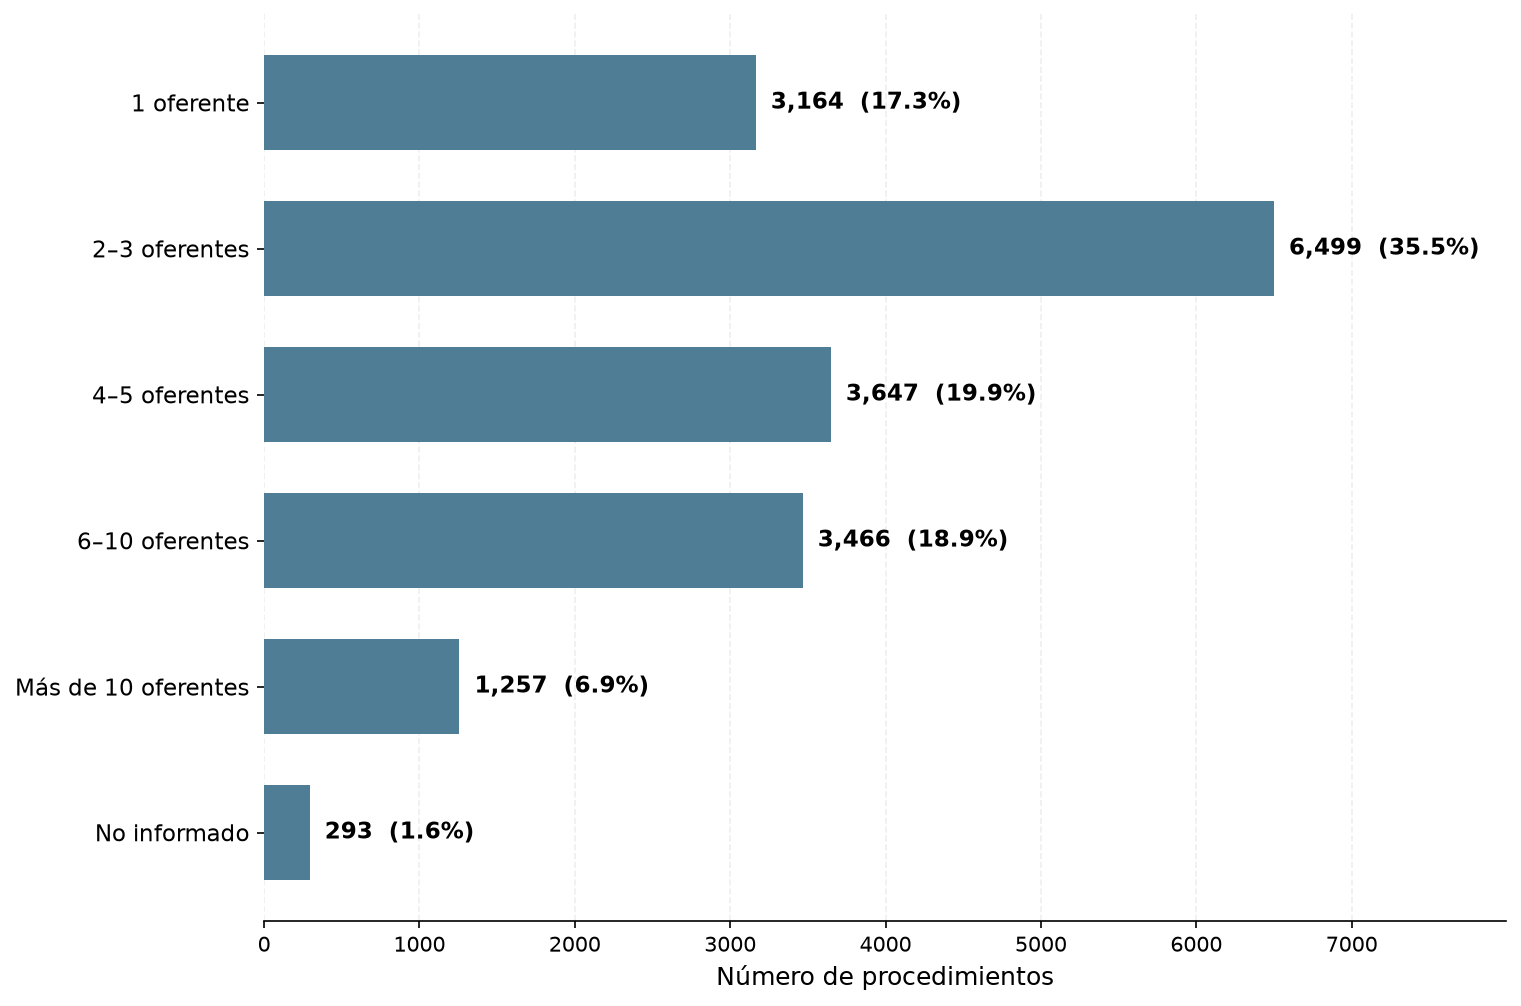

In [7]:
# ============================================================
# PASO 5. FIGURA 1
# PARTICIPACIÓN DE OFERENTES POR PROCEDIMIENTO
# ============================================================
# Objetivo:
# Describir cómo se distribuye el número de oferentes registrados
# en los procedimientos de Subasta Inversa Electrónica iniciados
# durante 2025.
#
# CRITERIOS METODOLÓGICOS:
# - Se utiliza el campo number_of_tenderers de la base limpia
#   de procedimientos.
# - Los valores faltantes se mantienen como "No informado".
# - Los valores iguales a cero se muestran separadamente como
#   "0 oferentes registrados".
# - Los valores faltantes NO se sustituyen por cero.
# - La figura es descriptiva.
# - No mide concentración, recurrencia, riesgo ni irregularidad.
# - Una baja participación debe interpretarse posteriormente
#   considerando las características del procedimiento y del
#   mercado correspondiente.
# ============================================================


from IPython.display import display


# ------------------------------------------------------------
# 1. Crear base para la visualización
# ------------------------------------------------------------

participacion_oferentes = procedimientos_df[
    [
        "ocid",
        "number_of_tenderers"
    ]
].copy()


# ------------------------------------------------------------
# 2. Convertir número de oferentes a formato numérico
# ------------------------------------------------------------

participacion_oferentes["numero_oferentes"] = pd.to_numeric(
    participacion_oferentes["number_of_tenderers"],
    errors="coerce"
)


# ------------------------------------------------------------
# 3. Controles iniciales de calidad
# ------------------------------------------------------------

total_procedimientos = len(
    participacion_oferentes
)

faltantes_oferentes = (
    participacion_oferentes[
        "numero_oferentes"
    ]
    .isna()
    .sum()
)

valores_cero = (
    participacion_oferentes[
        "numero_oferentes"
    ]
    .eq(0)
    .sum()
)

valores_negativos = (
    participacion_oferentes[
        "numero_oferentes"
    ]
    .lt(0)
    .sum()
)


print("=" * 65)
print("CONTROL DE PARTICIPACIÓN DE OFERENTES")
print("=" * 65)

print(
    f"\nTotal de procedimientos: "
    f"{total_procedimientos:,}"
)

print(
    f"Valores no informados/no convertibles: "
    f"{faltantes_oferentes:,}"
)

print(
    f"Procedimientos con 0 oferentes registrados: "
    f"{valores_cero:,}"
)

print(
    f"Valores negativos detectados: "
    f"{valores_negativos:,}"
)


# ------------------------------------------------------------
# 4. Clasificar procedimientos según número de oferentes
# ------------------------------------------------------------

def clasificar_participacion(numero):

    if pd.isna(numero):
        return "No informado"

    elif numero < 0:
        return "Dato no válido"

    elif numero == 0:
        return "0 oferentes registrados"

    elif numero == 1:
        return "1 oferente"

    elif 2 <= numero <= 3:
        return "2–3 oferentes"

    elif 4 <= numero <= 5:
        return "4–5 oferentes"

    elif 6 <= numero <= 10:
        return "6–10 oferentes"

    else:
        return "Más de 10 oferentes"


participacion_oferentes[
    "categoria_participacion"
] = (
    participacion_oferentes[
        "numero_oferentes"
    ]
    .apply(
        clasificar_participacion
    )
)


# ------------------------------------------------------------
# 5. Definir orden lógico de las categorías
# ------------------------------------------------------------

orden_categorias = [
    "0 oferentes registrados",
    "1 oferente",
    "2–3 oferentes",
    "4–5 oferentes",
    "6–10 oferentes",
    "Más de 10 oferentes",
    "No informado",
    "Dato no válido"
]


# ------------------------------------------------------------
# 6. Calcular cantidad de procedimientos por categoría
# ------------------------------------------------------------

tabla_participacion = (
    participacion_oferentes[
        "categoria_participacion"
    ]
    .value_counts()
    .reindex(
        orden_categorias,
        fill_value=0
    )
    .rename(
        "numero_procedimientos"
    )
    .reset_index()
    .rename(
        columns={
            "categoria_participacion": "participacion"
        }
    )
)


# ------------------------------------------------------------
# 7. Calcular porcentaje sobre el total
# ------------------------------------------------------------

tabla_participacion[
    "porcentaje"
] = (
    tabla_participacion[
        "numero_procedimientos"
    ]
    / total_procedimientos
    * 100
)


# ------------------------------------------------------------
# 8. Verificar que las categorías sumen el universo total
# ------------------------------------------------------------

total_clasificado = (
    tabla_participacion[
        "numero_procedimientos"
    ]
    .sum()
)


print(
    f"\nProcedimientos clasificados: "
    f"{total_clasificado:,}"
)

print(
    f"Procedimientos esperados: "
    f"{total_procedimientos:,}"
)


if total_clasificado == total_procedimientos:

    print(
        "VALIDACIÓN: Todos los procedimientos fueron "
        "clasificados correctamente."
    )

else:

    print(
        "ADVERTENCIA: La suma de las categorías no coincide "
        "con el total de procedimientos."
    )


# ------------------------------------------------------------
# 9. Mantener únicamente categorías con observaciones
# ------------------------------------------------------------

tabla_participacion_grafico = (
    tabla_participacion[
        tabla_participacion[
            "numero_procedimientos"
        ] > 0
    ]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 10. MOSTRAR TABLA DE RESULTADOS
# ============================================================
# Se utiliza un DataFrame normal, sin .style, para maximizar
# la compatibilidad entre PyCharm, Jupyter y otros entornos.
# ============================================================

print(
    "\nDISTRIBUCIÓN DE LA PARTICIPACIÓN DE OFERENTES\n"
)

display(
    tabla_participacion_grafico[
        [
            "participacion",
            "numero_procedimientos",
            "porcentaje"
        ]
    ]
)


# ============================================================
# 11. CREAR FIGURA 1
# ============================================================

fig, ax = plt.subplots(
    figsize=(11.5, 7.2),
    dpi=150
)


# ------------------------------------------------------------
# 12. Crear barras horizontales
# ------------------------------------------------------------

barras = ax.barh(
    tabla_participacion_grafico[
        "participacion"
    ],
    tabla_participacion_grafico[
        "numero_procedimientos"
    ],
    color="#4F7D95",
    height=0.65
)


# Colocar las categorías con menor participación arriba.
ax.invert_yaxis()


# ------------------------------------------------------------
# 13. Mostrar cantidad y porcentaje al final de cada barra
# ------------------------------------------------------------

maximo = (
    tabla_participacion_grafico[
        "numero_procedimientos"
    ]
    .max()
)


for barra, cantidad, porcentaje in zip(

    barras,

    tabla_participacion_grafico[
        "numero_procedimientos"
    ],

    tabla_participacion_grafico[
        "porcentaje"
    ]
):

    ax.text(
        barra.get_width()
        + maximo * 0.015,

        barra.get_y()
        + barra.get_height() / 2,

        f"{cantidad:,.0f}  ({porcentaje:.1f}%)",

        va="center",
        ha="left",

        fontsize=11,
        fontweight="bold"
    )


# ------------------------------------------------------------
# 14. Formato de los ejes
# ------------------------------------------------------------

ax.set_xlabel(
    "Número de procedimientos",
    fontsize=12
)

ax.set_ylabel("")


ax.tick_params(
    axis="y",
    labelsize=11
)

ax.tick_params(
    axis="x",
    labelsize=10
)


# ------------------------------------------------------------
# 15. Líneas guía suaves
# ------------------------------------------------------------

ax.xaxis.grid(
    True,
    linestyle="--",
    alpha=0.20
)

ax.set_axisbelow(True)


# ------------------------------------------------------------
# 16. Eliminar bordes innecesarios
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


# ------------------------------------------------------------
# 17. Dar espacio a cantidades y porcentajes
# ------------------------------------------------------------

ax.set_xlim(
    0,
    maximo * 1.23
)


# ------------------------------------------------------------
# 18. Ajustar márgenes
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.23,
    right=0.95,
    top=0.96,
    bottom=0.12
)


# ------------------------------------------------------------
# 19. Guardar Figura 1
# ------------------------------------------------------------

ruta_figura_1 = os.path.join(
    ruta_figuras,
    "figura_1_participacion_oferentes_2025.png"
)


fig.savefig(
    ruta_figura_1,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


print(
    "\nFigura 1 guardada en:"
)

print(
    ruta_figura_1
)


plt.show()

CONTROL DE MONTOS ADJUDICADOS

Registros iniciales: 15,718
Montos no informados/no convertibles: 0
Montos iguales a cero: 0
Montos negativos: 0

Adjudicaciones con monto válido > 0: 15,718

RESUMEN DESCRIPTIVO DE LOS MONTOS ADJUDICADOS



,estadistico,valor
0,Número de adjudicaciones válidas,1.571800e+04
1,Monto mínimo,1.754820e+03
2,Mediana,3.260126e+04
3,Percentil 90,1.994808e+05
4,Percentil 95,3.458755e+05
5,Percentil 99,1.006458e+06
6,Monto máximo,1.284006e+07
7,Adjudicaciones superiores al P99,1.580000e+02
8,Porcentaje superior al P99,1.005217e+00



Mediana: USD 32,601.26
Percentil 99: USD 1,006,458.20
Monto mínimo: USD 1,754.82
Monto máximo: USD 12,840,063.97
Adjudicaciones superiores al P99: 158 (1.01%)

Figura 2 guardada en:
../reports/figures/figura_2_distribucion_montos_adjudicados_2025.png


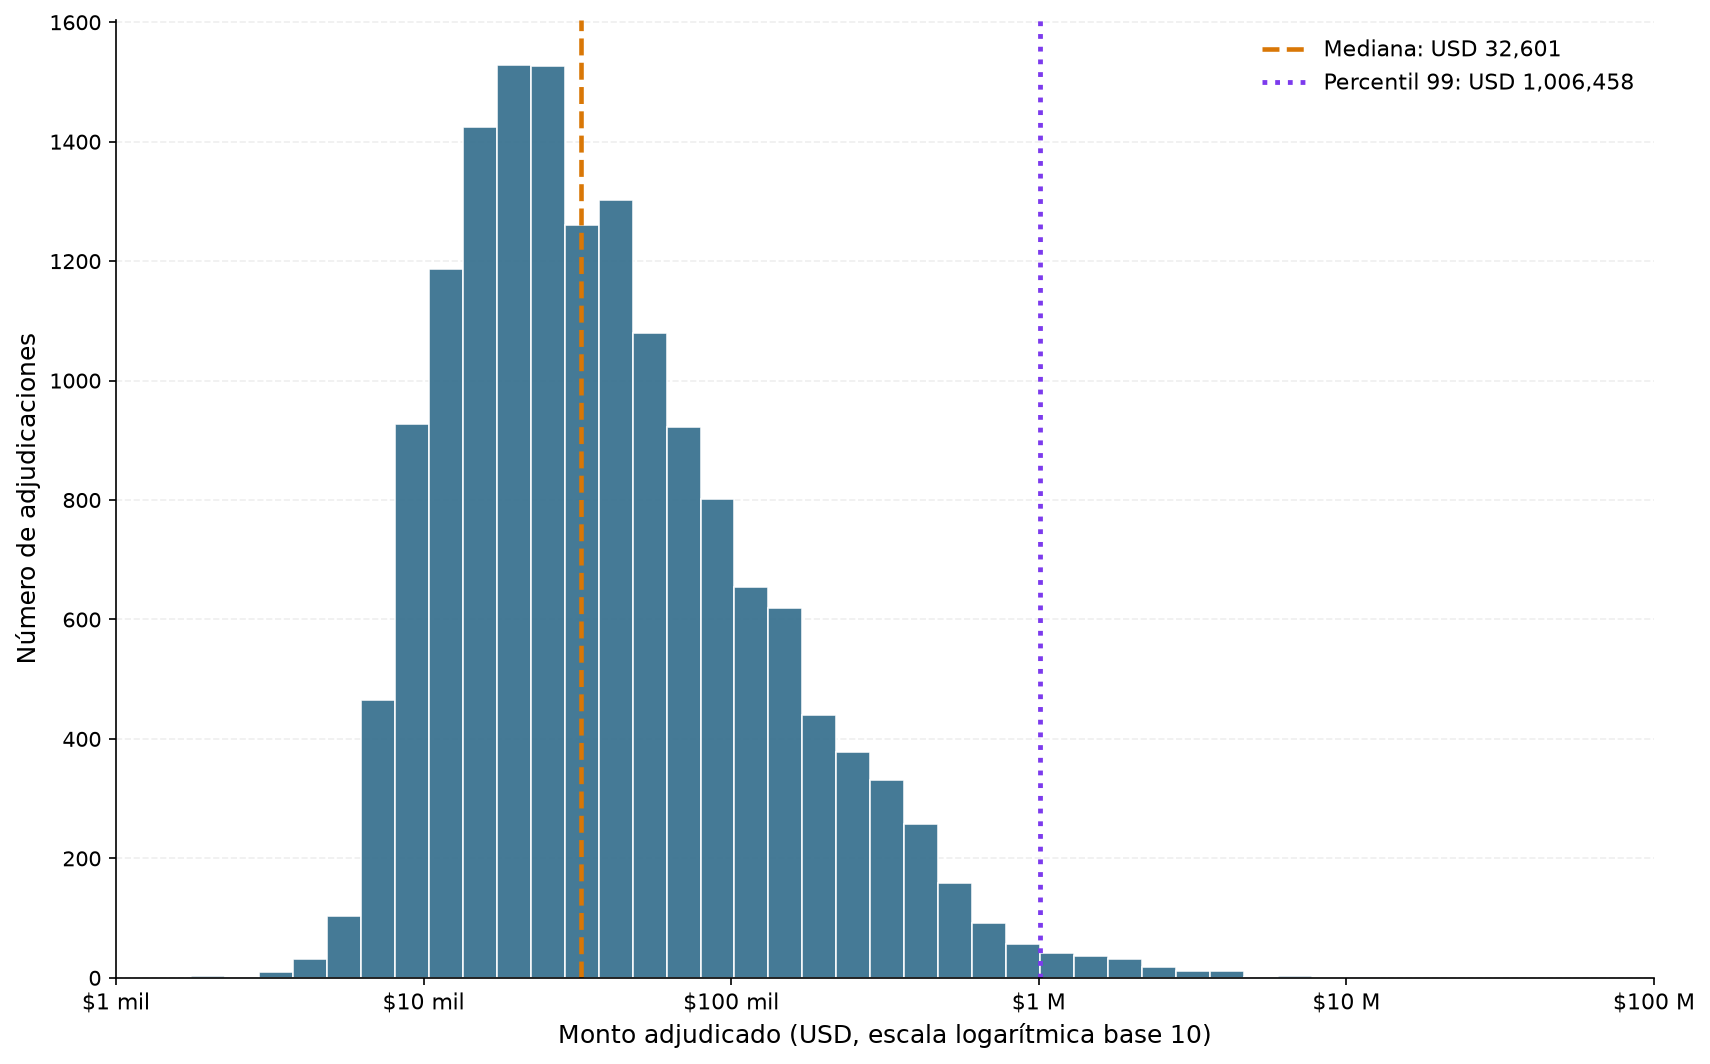

In [8]:
# ============================================================
# PASO 6. FIGURA 2
# DISTRIBUCIÓN DE LOS MONTOS ADJUDICADOS
# ============================================================
# Objetivo:
# Analizar la distribución de los montos adjudicados en los
# procedimientos de Subasta Inversa Electrónica iniciados
# durante 2025.
#
# CORRECCIÓN METODOLÓGICA SEGÚN OBSERVACIÓN DEL PROFESOR:
#
# - La distribución monetaria presenta fuerte asimetría positiva
#   y una cola superior extensa.
#
# - Se utiliza log10(monto) y NO log1p(monto), debido a que
#   previamente se conservan únicamente montos > 0.
#
# - Los valores extremos NO se eliminan.
#
# - Los valores extremos NO se winsorizan en esta figura,
#   porque el propósito es mostrar la distribución real de los
#   montos adjudicados.
#
# - El percentil 99 se utiliza únicamente como referencia para
#   evidenciar la presencia de la cola superior.
#
# - Esta figura NO mide concentración, recurrencia ni riesgo.
#
# IMPORTANTE:
# La winsorización se evaluará posteriormente en análisis donde
# los valores extremos puedan alterar comparaciones agregadas,
# como los rankings monetarios.
# ============================================================


from IPython.display import display


# ------------------------------------------------------------
# 1. Crear base para la Figura 2
# ------------------------------------------------------------

distribucion_montos = adjudicaciones_df[
    [
        "ocid",
        "award_amount"
    ]
].copy()


# ------------------------------------------------------------
# 2. Convertir el monto adjudicado a formato numérico
# ------------------------------------------------------------

distribucion_montos["award_amount"] = pd.to_numeric(
    distribucion_montos["award_amount"],
    errors="coerce"
)


# ------------------------------------------------------------
# 3. Controles iniciales de calidad
# ------------------------------------------------------------

total_registros_inicial = len(
    distribucion_montos
)

montos_no_informados = (
    distribucion_montos[
        "award_amount"
    ]
    .isna()
    .sum()
)

montos_cero = (
    distribucion_montos[
        "award_amount"
    ]
    .eq(0)
    .sum()
)

montos_negativos = (
    distribucion_montos[
        "award_amount"
    ]
    .lt(0)
    .sum()
)


print("=" * 65)
print("CONTROL DE MONTOS ADJUDICADOS")
print("=" * 65)

print(
    f"\nRegistros iniciales: "
    f"{total_registros_inicial:,}"
)

print(
    f"Montos no informados/no convertibles: "
    f"{montos_no_informados:,}"
)

print(
    f"Montos iguales a cero: "
    f"{montos_cero:,}"
)

print(
    f"Montos negativos: "
    f"{montos_negativos:,}"
)


# ------------------------------------------------------------
# 4. Mantener únicamente montos válidos y positivos
# ------------------------------------------------------------
# La transformación log10 requiere valores estrictamente
# positivos.
#
# No se eliminan valores por ser altos o extremos.
# ------------------------------------------------------------

distribucion_montos = distribucion_montos[
    distribucion_montos[
        "award_amount"
    ].notna()
    &
    (
        distribucion_montos[
            "award_amount"
        ] > 0
    )
].copy()


total_montos_validos = len(
    distribucion_montos
)


print(
    f"\nAdjudicaciones con monto válido > 0: "
    f"{total_montos_validos:,}"
)


# ------------------------------------------------------------
# 5. Calcular estadísticos descriptivos
# ------------------------------------------------------------

mediana_monto = (
    distribucion_montos[
        "award_amount"
    ]
    .median()
)

percentil_90 = (
    distribucion_montos[
        "award_amount"
    ]
    .quantile(0.90)
)

percentil_95 = (
    distribucion_montos[
        "award_amount"
    ]
    .quantile(0.95)
)

percentil_99 = (
    distribucion_montos[
        "award_amount"
    ]
    .quantile(0.99)
)

monto_minimo = (
    distribucion_montos[
        "award_amount"
    ]
    .min()
)

monto_maximo = (
    distribucion_montos[
        "award_amount"
    ]
    .max()
)


# ------------------------------------------------------------
# 6. Identificar observaciones superiores al P99
# ------------------------------------------------------------
# No se eliminan.
# Únicamente se cuantifican para documentar la cola extrema.
# ------------------------------------------------------------

cantidad_sobre_p99 = (
    distribucion_montos[
        "award_amount"
    ]
    > percentil_99
).sum()


porcentaje_sobre_p99 = (
    cantidad_sobre_p99
    / total_montos_validos
    * 100
)


# ------------------------------------------------------------
# 7. Crear tabla descriptiva de control
# ------------------------------------------------------------
# Se muestra como DataFrame normal para maximizar
# compatibilidad con PyCharm, Jupyter y VS Code.
# ------------------------------------------------------------

tabla_resumen_figura_2 = pd.DataFrame(
    {
        "estadistico": [
            "Número de adjudicaciones válidas",
            "Monto mínimo",
            "Mediana",
            "Percentil 90",
            "Percentil 95",
            "Percentil 99",
            "Monto máximo",
            "Adjudicaciones superiores al P99",
            "Porcentaje superior al P99"
        ],

        "valor": [
            total_montos_validos,
            monto_minimo,
            mediana_monto,
            percentil_90,
            percentil_95,
            percentil_99,
            monto_maximo,
            cantidad_sobre_p99,
            porcentaje_sobre_p99
        ]
    }
)


print(
    "\nRESUMEN DESCRIPTIVO DE LOS MONTOS ADJUDICADOS\n"
)

display(
    tabla_resumen_figura_2
)


# ------------------------------------------------------------
# 8. Mostrar controles numéricos principales
# ------------------------------------------------------------

print(
    f"\nMediana: "
    f"USD {mediana_monto:,.2f}"
)

print(
    f"Percentil 99: "
    f"USD {percentil_99:,.2f}"
)

print(
    f"Monto mínimo: "
    f"USD {monto_minimo:,.2f}"
)

print(
    f"Monto máximo: "
    f"USD {monto_maximo:,.2f}"
)

print(
    f"Adjudicaciones superiores al P99: "
    f"{cantidad_sobre_p99:,} "
    f"({porcentaje_sobre_p99:.2f}%)"
)


# ------------------------------------------------------------
# 9. Crear transformación log10
# ------------------------------------------------------------
# Se utiliza log10 y NO log1p.
#
# La columna award_amount original permanece intacta.
# ------------------------------------------------------------

distribucion_montos[
    "award_amount_log10"
] = np.log10(
    distribucion_montos[
        "award_amount"
    ]
)


# ------------------------------------------------------------
# 10. Transformar valores de referencia
# ------------------------------------------------------------

mediana_log10 = np.log10(
    mediana_monto
)

percentil_99_log10 = np.log10(
    percentil_99
)


# ============================================================
# 11. CREAR FIGURA 2
# ============================================================

fig, ax = plt.subplots(
    figsize=(11.5, 7.2),
    dpi=150
)


# ------------------------------------------------------------
# 12. Histograma de los montos originales transformados log10
# ------------------------------------------------------------
# Los bins tienen igual amplitud en escala logarítmica.
# Esto permite visualizar correctamente una distribución
# monetaria con varios órdenes de magnitud.
# ------------------------------------------------------------

ax.hist(
    distribucion_montos[
        "award_amount_log10"
    ],
    bins=35,
    color="#356F8D",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.92
)


# ------------------------------------------------------------
# 13. Línea de referencia: mediana
# ------------------------------------------------------------

ax.axvline(
    mediana_log10,
    color="#D97706",
    linestyle="--",
    linewidth=2.2,
    label=(
        f"Mediana: "
        f"USD {mediana_monto:,.0f}"
    )
)


# ------------------------------------------------------------
# 14. Línea de referencia: percentil 99
# ------------------------------------------------------------

ax.axvline(
    percentil_99_log10,
    color="#7C3AED",
    linestyle=":",
    linewidth=2.3,
    label=(
        f"Percentil 99: "
        f"USD {percentil_99:,.0f}"
    )
)


# ------------------------------------------------------------
# 15. Crear marcas del eje X según los datos reales
# ------------------------------------------------------------
# Cada unidad corresponde a una potencia de 10:
#
# log10(1,000)     = 3
# log10(10,000)    = 4
# log10(100,000)   = 5
# log10(1,000,000) = 6
# ------------------------------------------------------------

exponente_min = int(
    np.floor(
        distribucion_montos[
            "award_amount_log10"
        ].min()
    )
)

exponente_max = int(
    np.ceil(
        distribucion_montos[
            "award_amount_log10"
        ].max()
    )
)


ticks_log = list(
    range(
        exponente_min,
        exponente_max + 1
    )
)


# ------------------------------------------------------------
# 16. Función para mostrar los valores del eje X en USD
# ------------------------------------------------------------

def formato_monto_log(exponente):

    valor_monetario = 10 ** exponente

    if valor_monetario >= 1_000_000_000:

        return (
            f"${valor_monetario / 1_000_000_000:g} mil M"
        )

    elif valor_monetario >= 1_000_000:

        return (
            f"${valor_monetario / 1_000_000:g} M"
        )

    elif valor_monetario >= 1_000:

        return (
            f"${valor_monetario / 1_000:g} mil"
        )

    else:

        return (
            f"${valor_monetario:g}"
        )


etiquetas_ticks = [
    formato_monto_log(
        exponente
    )
    for exponente in ticks_log
]


ax.set_xticks(
    ticks_log
)

ax.set_xticklabels(
    etiquetas_ticks,
    fontsize=10.5
)


# ------------------------------------------------------------
# 17. Etiquetas de los ejes
# ------------------------------------------------------------

ax.set_xlabel(
    "Monto adjudicado (USD, escala logarítmica base 10)",
    fontsize=12
)

ax.set_ylabel(
    "Número de adjudicaciones",
    fontsize=12
)


# ------------------------------------------------------------
# 18. Tamaño de etiquetas
# ------------------------------------------------------------

ax.tick_params(
    axis="y",
    labelsize=10
)


# ------------------------------------------------------------
# 19. Líneas guía suaves
# ------------------------------------------------------------

ax.yaxis.grid(
    True,
    linestyle="--",
    alpha=0.20
)

ax.set_axisbelow(True)


# ------------------------------------------------------------
# 20. Eliminar bordes innecesarios
# ------------------------------------------------------------

ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)


# ------------------------------------------------------------
# 21. Leyenda
# ------------------------------------------------------------

ax.legend(
    frameon=False,
    fontsize=10.5,
    loc="upper right"
)


# ------------------------------------------------------------
# 22. Ajustar márgenes
# ------------------------------------------------------------

plt.tight_layout()


# ------------------------------------------------------------
# 23. Guardar Figura 2
# ------------------------------------------------------------

ruta_figura_2 = os.path.join(
    ruta_figuras,
    "figura_2_distribucion_montos_adjudicados_2025.png"
)


fig.savefig(
    ruta_figura_2,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


print(
    "\nFigura 2 guardada en:"
)

print(
    ruta_figura_2
)


plt.show()

CONTROL DE FIGURA 3 - MONTO POR PROVEEDOR

Adjudicaciones válidas utilizadas: 15,718
Proveedores identificados: 5,969

Percentil 99 de adjudicaciones individuales: USD 1,006,458.20
Adjudicaciones superiores al P99: 158 (1.01%)

Proveedores que coinciden entre Top 10 original y Top 10 winsorizado: 6 de 10
RESULTADO: La winsorización modifica la composición del Top 10, lo que confirma que los valores extremos influían en el ranking.

TOP 10 PROVEEDORES POR MONTO TOTAL ADJUDICADO
Ranking robusto mediante winsorización al P99



,Ranking P99,Proveedor,Monto original,Monto winsorizado P99,Reducción,N.º adjudicaciones,Adjudicaciones > P99,Ranking original
0,1,SIMED S. A.,"USD 15,550,452.12","USD 14,547,710.53",6.45%,73,2,2
1,2,ROCHE ECUADOR S.A.,"USD 16,714,468.04","USD 13,575,886.25",18.78%,42,4,1
2,3,MAQUINARIAS Y VEHICULOS S.A. MAVESA,"USD 11,335,827.97","USD 9,499,644.37",16.20%,44,2,4
3,4,MEDILABOR S.A.,"USD 7,713,656.23","USD 7,713,656.23",0.00%,69,0,9
4,5,DITECA S.A.,"USD 11,309,184.23","USD 6,917,508.91",38.83%,21,4,5
5,6,CORPORACION MAD GU CORPORACIONMADGU S.A.,"USD 6,698,463.03","USD 6,698,463.03",0.00%,26,0,12
6,7,COMPANIA COMERCIAL REINA VICTORIA S.A COMREIVIC,"USD 6,318,113.12","USD 6,318,113.12",0.00%,14,0,18
7,8,FATOSLA C.A.,"USD 9,492,313.06","USD 5,939,081.04",37.43%,14,2,7
8,9,B.BRAUN MEDICAL S.A.,"USD 5,610,642.26","USD 5,610,642.26",0.00%,85,0,22
9,10,VIBAG C.A.,"USD 5,474,175.26","USD 5,474,175.26",0.00%,56,0,24



Figura 3 guardada en:
../reports/figures/figura_3_proveedores_mayor_monto_winsorizado_2025.png


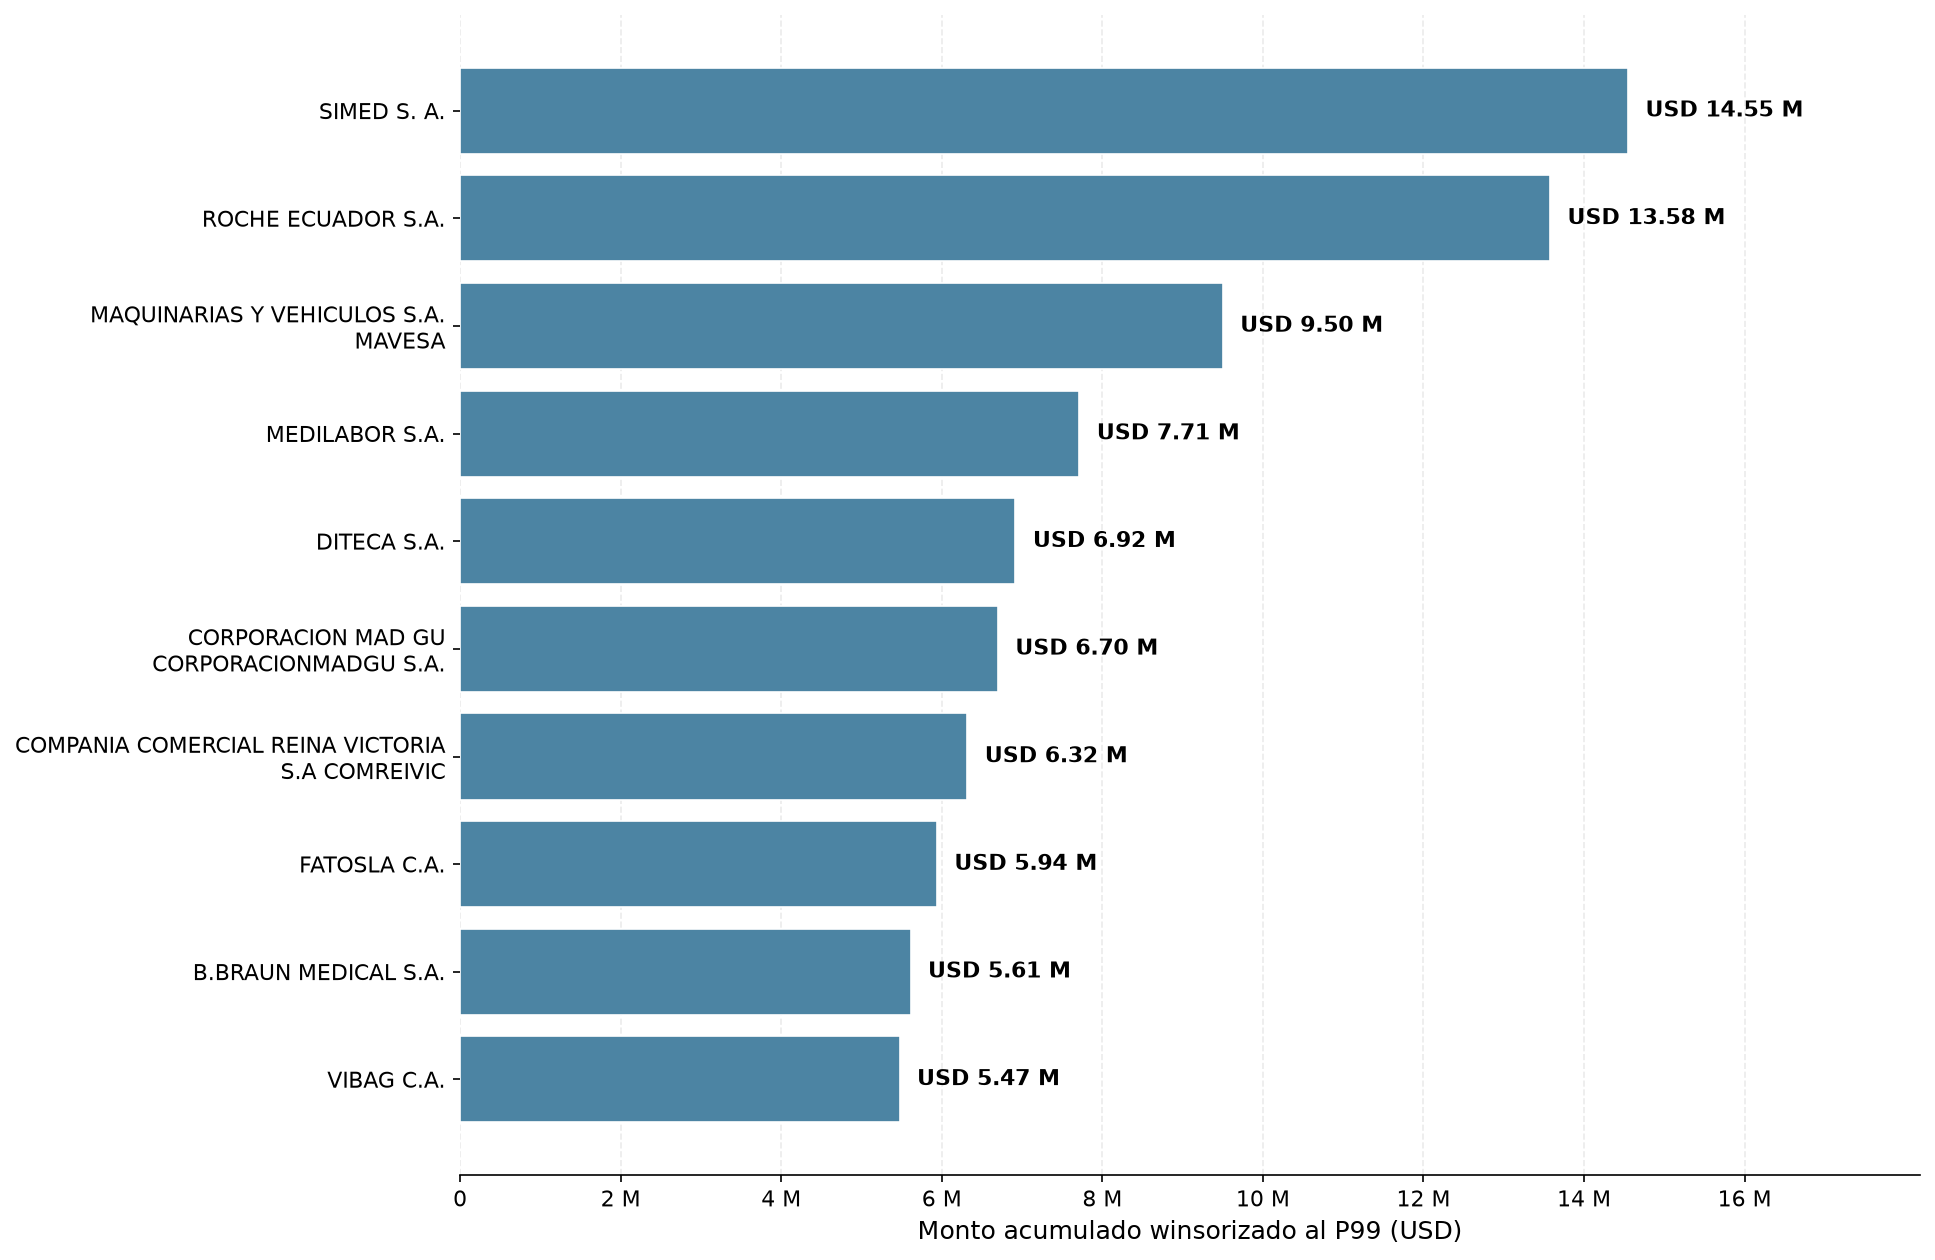

In [7]:
# ============================================================
# PASO 7. FIGURA 3
# PROVEEDORES CON MAYOR MONTO TOTAL ADJUDICADO
# ============================================================
# Objetivo:
# Identificar los proveedores con mayor participación económica
# acumulada en los procedimientos de Subasta Inversa
# Electrónica iniciados durante 2025.
#
# CORRECCIÓN METODOLÓGICA SEGÚN OBSERVACIÓN DEL PROFESOR:
#
# - Los montos adjudicados presentan una cola superior extensa.
# - Un número reducido de adjudicaciones extraordinariamente
#   altas puede modificar de manera importante un ranking
#   construido únicamente con montos acumulados originales.
#
# - Por esta razón, se realiza un análisis robusto mediante
#   winsorización al percentil 99 (P99) de las adjudicaciones
#   individuales antes de acumular los montos por proveedor.
#
# IMPORTANTE:
# - El monto original NO se elimina ni se reemplaza.
# - Se calculan y conservan ambos valores:
#       1. monto total original
#       2. monto total winsorizado al P99
# - El ranking de la Figura 3 se construye utilizando el monto
#   winsorizado al P99.
# - La tabla permite comparar el resultado original y robusto.
# - La frecuencia se muestra únicamente como información
#   descriptiva y se analizará separadamente en la Figura 4.
# - Esta figura NO mide concentración, recurrencia, riesgo
#   ni irregularidad.
# ============================================================


import os
import textwrap
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ------------------------------------------------------------
# 1. Crear base para la Figura 3
# ------------------------------------------------------------

figura_3_df = adjudicaciones_df[
    [
        "ocid",
        "supplier_id",
        "nombre_proveedor_limpio",
        "award_amount"
    ]
].copy()


# ------------------------------------------------------------
# 2. Convertir monto a formato numérico
# ------------------------------------------------------------

figura_3_df["award_amount"] = pd.to_numeric(
    figura_3_df["award_amount"],
    errors="coerce"
)


# ------------------------------------------------------------
# 3. Mantener únicamente registros válidos
# ------------------------------------------------------------

figura_3_df = figura_3_df[
    figura_3_df["supplier_id"].notna()
    & figura_3_df["award_amount"].notna()
    & (figura_3_df["award_amount"] > 0)
].copy()


print("=" * 70)
print("CONTROL DE FIGURA 3 - MONTO POR PROVEEDOR")
print("=" * 70)

print(
    f"\nAdjudicaciones válidas utilizadas: "
    f"{len(figura_3_df):,}"
)

print(
    f"Proveedores identificados: "
    f"{figura_3_df['supplier_id'].nunique():,}"
)


# ============================================================
# 4. DETERMINAR LÍMITE DE WINSORIZACIÓN
# ============================================================
# El P99 se calcula sobre las adjudicaciones individuales,
# antes de sumar los montos por proveedor.
#
# Esto controla el efecto de adjudicaciones excepcionalmente
# altas sin eliminar registros de la base.
# ============================================================

percentil_99_figura_3 = (
    figura_3_df["award_amount"]
    .quantile(0.99)
)


print(
    f"\nPercentil 99 de adjudicaciones individuales: "
    f"USD {percentil_99_figura_3:,.2f}"
)


# ------------------------------------------------------------
# 5. Identificar adjudicaciones superiores al P99
# ------------------------------------------------------------

figura_3_df["supera_p99"] = (
    figura_3_df["award_amount"]
    > percentil_99_figura_3
)


cantidad_supera_p99 = (
    figura_3_df["supera_p99"]
    .sum()
)


porcentaje_supera_p99 = (
    cantidad_supera_p99
    / len(figura_3_df)
    * 100
)


print(
    f"Adjudicaciones superiores al P99: "
    f"{cantidad_supera_p99:,} "
    f"({porcentaje_supera_p99:.2f}%)"
)


# ============================================================
# 6. CREAR MONTO WINSORIZADO
# ============================================================
# Únicamente las adjudicaciones superiores al P99 se limitan
# al valor del P99.
#
# award_amount permanece intacta.
# ============================================================

figura_3_df[
    "award_amount_winsor_p99"
] = (
    figura_3_df["award_amount"]
    .clip(
        upper=percentil_99_figura_3
    )
)


# ============================================================
# 7. CONSOLIDAR NOMBRE DEL PROVEEDOR
# ============================================================
# supplier_id se mantiene como identificador principal.
#
# Si para un mismo supplier_id existieran varias formas del
# nombre, se utiliza el nombre limpio más frecuente únicamente
# para fines de visualización.
# ============================================================

def nombre_representativo(serie):

    serie = serie.dropna()

    if len(serie) == 0:
        return None

    moda = serie.mode()

    if len(moda) > 0:
        return moda.iloc[0]

    return serie.iloc[0]


nombres_proveedor = (
    figura_3_df
    .groupby(
        "supplier_id",
        as_index=False
    )
    .agg(
        nombre_grafico=(
            "nombre_proveedor_limpio",
            nombre_representativo
        )
    )
)


# ============================================================
# 8. AGRUPAR POR PROVEEDOR
# ============================================================
# Se calculan por separado:
#
# - monto total original
# - monto total winsorizado
# - número de procedimientos adjudicados
# - número de adjudicaciones afectadas por el P99
# ============================================================

proveedores_monto = (
    figura_3_df
    .groupby(
        "supplier_id",
        as_index=False
    )
    .agg(

        monto_total_original=(
            "award_amount",
            "sum"
        ),

        monto_total_winsor_p99=(
            "award_amount_winsor_p99",
            "sum"
        ),

        numero_adjudicaciones=(
            "ocid",
            "nunique"
        ),

        adjudicaciones_superiores_p99=(
            "supera_p99",
            "sum"
        )
    )
)


# ------------------------------------------------------------
# 9. Incorporar nombre limpio
# ------------------------------------------------------------

proveedores_monto = (
    proveedores_monto
    .merge(
        nombres_proveedor,
        on="supplier_id",
        how="left"
    )
)


# Si no existe nombre, utilizar supplier_id

proveedores_monto["nombre_grafico"] = (
    proveedores_monto["nombre_grafico"]
    .fillna(
        proveedores_monto["supplier_id"]
    )
)


# ============================================================
# 10. CALCULAR EFECTO DE LA WINSORIZACIÓN
# ============================================================

proveedores_monto[
    "diferencia_winsorizacion"
] = (
    proveedores_monto[
        "monto_total_original"
    ]
    -
    proveedores_monto[
        "monto_total_winsor_p99"
    ]
)


proveedores_monto[
    "reduccion_porcentual"
] = (
    proveedores_monto[
        "diferencia_winsorizacion"
    ]
    /
    proveedores_monto[
        "monto_total_original"
    ]
    * 100
)


# ============================================================
# 11. CALCULAR RANKING ORIGINAL Y RANKING ROBUSTO
# ============================================================

proveedores_monto[
    "ranking_original"
] = (
    proveedores_monto[
        "monto_total_original"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)


proveedores_monto[
    "ranking_winsor_p99"
] = (
    proveedores_monto[
        "monto_total_winsor_p99"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)


# ============================================================
# 12. SELECCIONAR TOP 10 ROBUSTO
# ============================================================
# El ranking definitivo de la Figura 3 utiliza el monto
# acumulado winsorizado al P99.
# ============================================================

top_monto = (
    proveedores_monto
    .sort_values(
        "monto_total_winsor_p99",
        ascending=False
    )
    .head(10)
    .copy()
)


# ============================================================
# 13. COMPROBAR SI LA WINSORIZACIÓN CAMBIA EL TOP 10
# ============================================================

top_original_ids = set(
    proveedores_monto
    .sort_values(
        "monto_total_original",
        ascending=False
    )
    .head(10)["supplier_id"]
)


top_winsor_ids = set(
    top_monto["supplier_id"]
)


coincidencias_top10 = len(
    top_original_ids
    .intersection(
        top_winsor_ids
    )
)


print(
    f"\nProveedores que coinciden entre "
    f"Top 10 original y Top 10 winsorizado: "
    f"{coincidencias_top10} de 10"
)


if coincidencias_top10 == 10:

    print(
        "VALIDACIÓN: La winsorización no cambia la "
        "composición del Top 10, aunque puede modificar "
        "el orden y las diferencias monetarias."
    )

else:

    print(
        "RESULTADO: La winsorización modifica la "
        "composición del Top 10, lo que confirma que "
        "los valores extremos influían en el ranking."
    )


# ============================================================
# 14. CREAR TABLA DE RESULTADOS
# ============================================================

tabla_figura_3 = (
    top_monto[
        [
            "ranking_winsor_p99",
            "nombre_grafico",
            "monto_total_original",
            "monto_total_winsor_p99",
            "reduccion_porcentual",
            "numero_adjudicaciones",
            "adjudicaciones_superiores_p99",
            "ranking_original"
        ]
    ]
    .sort_values(
        "ranking_winsor_p99"
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Crear copia únicamente para presentación
# ------------------------------------------------------------

tabla_figura_3_mostrar = (
    tabla_figura_3.copy()
)


tabla_figura_3_mostrar = (
    tabla_figura_3_mostrar.rename(
        columns={
            "ranking_winsor_p99":
                "Ranking P99",

            "nombre_grafico":
                "Proveedor",

            "monto_total_original":
                "Monto original",

            "monto_total_winsor_p99":
                "Monto winsorizado P99",

            "reduccion_porcentual":
                "Reducción",

            "numero_adjudicaciones":
                "N.º adjudicaciones",

            "adjudicaciones_superiores_p99":
                "Adjudicaciones > P99",

            "ranking_original":
                "Ranking original"
        }
    )
)


# Formato únicamente para mostrar la tabla.

tabla_figura_3_mostrar[
    "Monto original"
] = (
    tabla_figura_3_mostrar[
        "Monto original"
    ]
    .map(
        lambda x: f"USD {x:,.2f}"
    )
)


tabla_figura_3_mostrar[
    "Monto winsorizado P99"
] = (
    tabla_figura_3_mostrar[
        "Monto winsorizado P99"
    ]
    .map(
        lambda x: f"USD {x:,.2f}"
    )
)


tabla_figura_3_mostrar[
    "Reducción"
] = (
    tabla_figura_3_mostrar[
        "Reducción"
    ]
    .map(
        lambda x: f"{x:.2f}%"
    )
)


print(
    "\nTOP 10 PROVEEDORES POR MONTO TOTAL ADJUDICADO"
)

print(
    "Ranking robusto mediante winsorización al P99\n"
)


display(
    tabla_figura_3_mostrar
)


# ============================================================
# 15. PREPARAR NOMBRES PARA LA FIGURA
# ============================================================
# Los nombres completos se mantienen.
# Cuando son largos, se dividen en varias líneas.
# ============================================================

def envolver_texto(
    texto,
    ancho=34
):

    texto = str(
        texto
    )

    return "\n".join(
        textwrap.wrap(
            texto,
            width=ancho,
            break_long_words=False,
            break_on_hyphens=False
        )
    )


top_monto[
    "nombre_grafico_ajustado"
] = (
    top_monto[
        "nombre_grafico"
    ]
    .apply(
        lambda x:
        envolver_texto(
            x,
            ancho=34
        )
    )
)


# ------------------------------------------------------------
# Ordenar para gráfico horizontal
# ------------------------------------------------------------

top_monto_grafico = (
    top_monto
    .sort_values(
        "monto_total_winsor_p99",
        ascending=True
    )
    .copy()
)


# ============================================================
# 16. CREAR FIGURA 3
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 8.5),
    dpi=150
)


barras = ax.barh(
    top_monto_grafico[
        "nombre_grafico_ajustado"
    ],
    top_monto_grafico[
        "monto_total_winsor_p99"
    ],
    color="#4C84A3",
    edgecolor="white",
    linewidth=0.8
)


# ============================================================
# 17. ETIQUETAS AL FINAL DE CADA BARRA
# ============================================================

max_monto = (
    top_monto_grafico[
        "monto_total_winsor_p99"
    ]
    .max()
)


for barra, valor in zip(

    barras,

    top_monto_grafico[
        "monto_total_winsor_p99"
    ]
):

    ax.text(

        valor
        + max_monto * 0.015,

        barra.get_y()
        + barra.get_height() / 2,

        f"USD {valor / 1_000_000:.2f} M",

        va="center",
        ha="left",

        fontsize=10.5,
        fontweight="bold"
    )


# ============================================================
# 18. FORMATO DEL EJE X
# ============================================================

ax.set_xlabel(
    "Monto acumulado winsorizado al P99 (USD)",
    fontsize=12
)

ax.set_ylabel("")


# ------------------------------------------------------------
# Formato del eje X en millones
# ------------------------------------------------------------

ax.ticklabel_format(
    style="plain",
    axis="x"
)


ticks = (
    ax.get_xticks()
)


ticks_validos = [
    tick
    for tick in ticks
    if tick >= 0
]


ax.set_xticks(
    ticks_validos
)


ax.set_xticklabels(
    [
        (
            f"{tick / 1_000_000:.0f} M"
            if tick > 0
            else "0"
        )
        for tick in ticks_validos
    ],
    fontsize=10.5
)


# ------------------------------------------------------------
# Tamaño de nombres de proveedores
# ------------------------------------------------------------

ax.tick_params(
    axis="y",
    labelsize=10.5
)


# ============================================================
# 19. ESTILO VISUAL
# ============================================================

ax.xaxis.grid(
    True,
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)


ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)

ax.spines[
    "left"
].set_visible(False)


# ------------------------------------------------------------
# Dar espacio a las etiquetas monetarias
# ------------------------------------------------------------

ax.set_xlim(
    0,
    max_monto * 1.25
)


# ============================================================
# 20. AJUSTE FINAL
# ============================================================

plt.tight_layout()


# ============================================================
# 21. GUARDAR FIGURA 3
# ============================================================

ruta_figura_3 = os.path.join(
    ruta_figuras,
    "figura_3_proveedores_mayor_monto_winsorizado_2025.png"
)


fig.savefig(
    ruta_figura_3,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


print(
    "\nFigura 3 guardada en:"
)

print(
    ruta_figura_3
)


plt.show()

CONTROL DE FIGURA 4 - FRECUENCIA DE ADJUDICACIONES

Registros de adjudicación utilizados: 15,718
Proveedores identificados: 5,969
Procedimientos distintos presentes: 15,718

TOP 10 PROVEEDORES POR NÚMERO DE ADJUDICACIONES



,Ranking,Proveedor,Número de adjudicaciones
0,1,PRODUCTOS Y DISTRIBUCIONES MEDICAS ANDINO PROD...,96
1,2,B.BRAUN MEDICAL S.A.,85
2,3,LABORATORIO VIDA (LABOVIDA) S.A.,76
3,4,SIMED S. A.,73
4,5,MEDILABOR S.A.,69
5,6,ESTRELLA SANGO MIGUEL ANGEL,67
6,7,REACTLAB IMPORT CIA. LTDA,56
7,7,VIBAG C.A.,56
8,9,TELCONET S.A.,52
9,10,ECUAQUIMICA ECUATORIANA DE PRODUCTOS QUIMICOS ...,50



Figura 4 guardada en:
../reports/figures/figura_4_proveedores_mayor_numero_adjudicaciones_2025.png


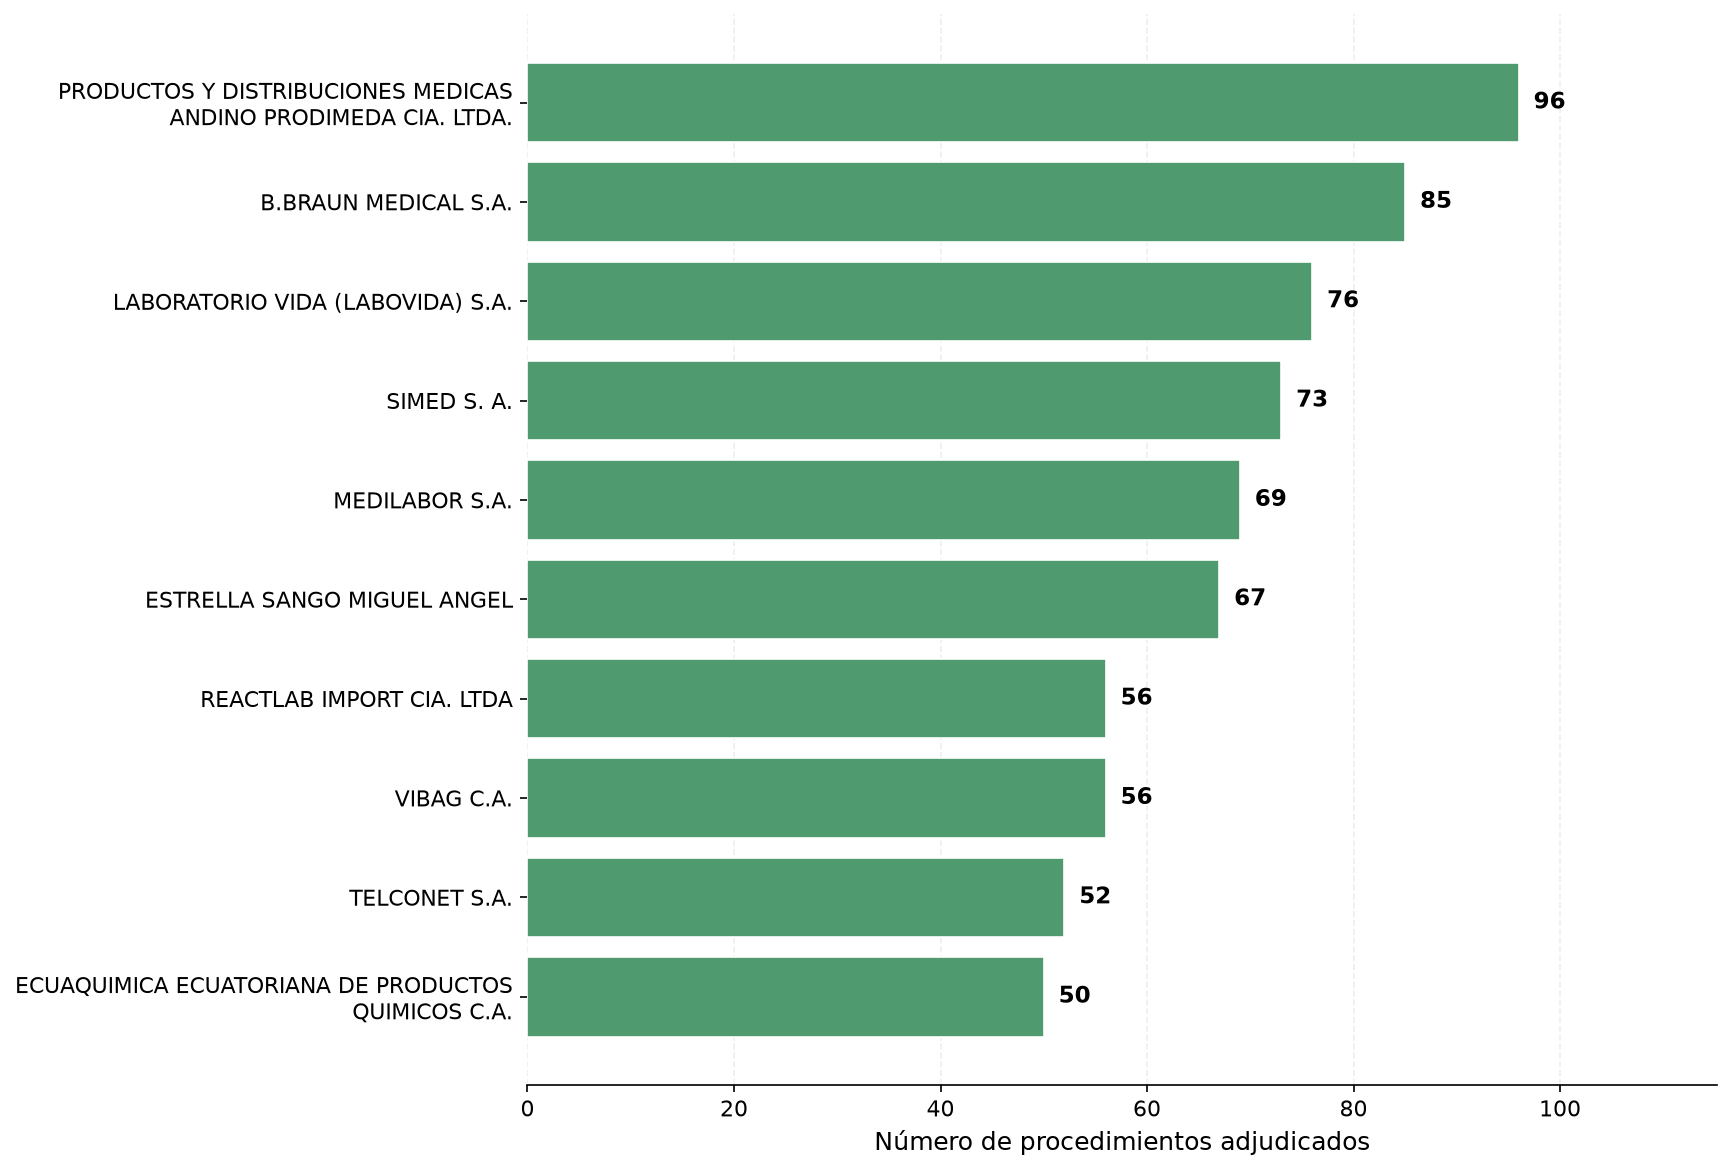

In [10]:
# ============================================================
# PASO 8. FIGURA 4
# PROVEEDORES CON MAYOR NÚMERO DE ADJUDICACIONES
# ============================================================
# Objetivo:
# Identificar los proveedores que participaron con mayor
# frecuencia como adjudicatarios en los procedimientos de
# Subasta Inversa Electrónica iniciados durante 2025.
#
# CRITERIO METODOLÓGICO:
#
# - La frecuencia se mide mediante el número de procedimientos
#   distintos (ocid) adjudicados a cada proveedor.
#
# - supplier_id se utiliza como identificador principal.
#
# - nombre_proveedor_limpio se utiliza únicamente para
#   presentación.
#
# - NO se utilizan montos para construir este ranking.
#
# - NO se aplica winsorización porque aquí se analiza frecuencia,
#   no magnitud monetaria.
#
# - NO se aplica el filtro de >= 5 adjudicaciones utilizado
#   posteriormente para el análisis de concentración mediante HHI.
#
# - Esta figura NO mide concentración, recurrencia, riesgo
#   ni irregularidad.
#
# - Un proveedor con muchas adjudicaciones puede tener una
#   participación frecuente sin necesariamente concentrar
#   una proporción elevada del monto económico.
#
# La Figura 4 complementa la Figura 3, permitiendo comparar
# participación económica y frecuencia de manera diferenciada,
# conforme a la observación metodológica del profesor.
# ============================================================


import os
import textwrap
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ------------------------------------------------------------
# 1. Crear base para la Figura 4
# ------------------------------------------------------------

figura_4_df = adjudicaciones_df[
    [
        "ocid",
        "supplier_id",
        "nombre_proveedor_limpio"
    ]
].copy()


# ------------------------------------------------------------
# 2. Mantener únicamente registros con identificador válido
# ------------------------------------------------------------

figura_4_df = figura_4_df[
    figura_4_df["supplier_id"].notna()
    & figura_4_df["ocid"].notna()
].copy()


# ------------------------------------------------------------
# 3. Controles iniciales
# ------------------------------------------------------------

print("=" * 70)
print("CONTROL DE FIGURA 4 - FRECUENCIA DE ADJUDICACIONES")
print("=" * 70)

print(
    f"\nRegistros de adjudicación utilizados: "
    f"{len(figura_4_df):,}"
)

print(
    f"Proveedores identificados: "
    f"{figura_4_df['supplier_id'].nunique():,}"
)

print(
    f"Procedimientos distintos presentes: "
    f"{figura_4_df['ocid'].nunique():,}"
)


# ============================================================
# 4. CONSOLIDAR NOMBRE DEL PROVEEDOR
# ============================================================
# supplier_id se mantiene como identificador principal.
#
# En caso de que un mismo supplier_id aparezca con más de una
# forma del nombre, se selecciona el nombre limpio más frecuente
# únicamente para fines de visualización.
# ============================================================

def nombre_representativo(serie):

    serie = serie.dropna()

    if len(serie) == 0:
        return None

    moda = serie.mode()

    if len(moda) > 0:
        return moda.iloc[0]

    return serie.iloc[0]


nombres_proveedor_figura_4 = (
    figura_4_df
    .groupby(
        "supplier_id",
        as_index=False
    )
    .agg(
        nombre_grafico=(
            "nombre_proveedor_limpio",
            nombre_representativo
        )
    )
)


# ------------------------------------------------------------
# Si no existe nombre limpio, mostrar supplier_id
# ------------------------------------------------------------

nombres_proveedor_figura_4[
    "nombre_grafico"
] = (
    nombres_proveedor_figura_4[
        "nombre_grafico"
    ]
    .fillna(
        nombres_proveedor_figura_4[
            "supplier_id"
        ]
    )
)


# ============================================================
# 5. CALCULAR FRECUENCIA POR PROVEEDOR
# ============================================================
# Se utiliza nunique(ocid) para evitar contar más de una vez
# un mismo procedimiento para el mismo proveedor.
# ============================================================

proveedores_frecuencia = (
    figura_4_df
    .groupby(
        "supplier_id",
        as_index=False
    )
    .agg(
        numero_adjudicaciones=(
            "ocid",
            "nunique"
        )
    )
)


# ------------------------------------------------------------
# 6. Incorporar nombre del proveedor
# ------------------------------------------------------------

proveedores_frecuencia = (
    proveedores_frecuencia
    .merge(
        nombres_proveedor_figura_4,
        on="supplier_id",
        how="left"
    )
)


# ============================================================
# 7. CREAR RANKING DE FRECUENCIA
# ============================================================

proveedores_frecuencia[
    "ranking_frecuencia"
] = (
    proveedores_frecuencia[
        "numero_adjudicaciones"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)


# ============================================================
# 8. SELECCIONAR TOP 10
# ============================================================

top_frecuencia = (
    proveedores_frecuencia
    .sort_values(
        [
            "numero_adjudicaciones",
            "nombre_grafico"
        ],
        ascending=[
            False,
            True
        ]
    )
    .head(10)
    .copy()
)


# ============================================================
# 9. CREAR TABLA DE RESULTADOS
# ============================================================

tabla_figura_4 = (
    top_frecuencia[
        [
            "ranking_frecuencia",
            "nombre_grafico",
            "numero_adjudicaciones"
        ]
    ]
    .sort_values(
        [
            "numero_adjudicaciones",
            "nombre_grafico"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)


tabla_figura_4 = (
    tabla_figura_4.rename(
        columns={
            "ranking_frecuencia":
                "Ranking",

            "nombre_grafico":
                "Proveedor",

            "numero_adjudicaciones":
                "Número de adjudicaciones"
        }
    )
)


print(
    "\nTOP 10 PROVEEDORES POR NÚMERO DE ADJUDICACIONES\n"
)


# DataFrame normal para máxima compatibilidad
# con PyCharm, Jupyter y VS Code.

display(
    tabla_figura_4
)


# ============================================================
# 10. PREPARAR NOMBRES COMPLETOS PARA LA FIGURA
# ============================================================
# Los nombres no se recortan con "...".
# Cuando son extensos se dividen en varias líneas.
# ============================================================

def envolver_texto_figura_4(
    texto,
    ancho=38
):

    texto = str(
        texto
    )

    return "\n".join(
        textwrap.wrap(
            texto,
            width=ancho,
            break_long_words=False,
            break_on_hyphens=False
        )
    )


top_frecuencia[
    "nombre_grafico_ajustado"
] = (
    top_frecuencia[
        "nombre_grafico"
    ]
    .apply(
        lambda x:
        envolver_texto_figura_4(
            x,
            ancho=38
        )
    )
)


# ------------------------------------------------------------
# Ordenar de menor a mayor para gráfico horizontal
# ------------------------------------------------------------

top_frecuencia_grafico = (
    top_frecuencia
    .sort_values(
        [
            "numero_adjudicaciones",
            "nombre_grafico"
        ],
        ascending=[
            True,
            False
        ]
    )
    .copy()
)


# ============================================================
# 11. CREAR FIGURA 4
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 8.5),
    dpi=150
)


barras = ax.barh(
    top_frecuencia_grafico[
        "nombre_grafico_ajustado"
    ],
    top_frecuencia_grafico[
        "numero_adjudicaciones"
    ],
    color="#4F9A6E",
    edgecolor="white",
    linewidth=0.8
)


# ============================================================
# 12. MOSTRAR NÚMERO DE ADJUDICACIONES
# ============================================================

max_frecuencia = (
    top_frecuencia_grafico[
        "numero_adjudicaciones"
    ]
    .max()
)


for barra, valor in zip(

    barras,

    top_frecuencia_grafico[
        "numero_adjudicaciones"
    ]
):

    ax.text(
        valor
        + max_frecuencia * 0.015,

        barra.get_y()
        + barra.get_height() / 2,

        f"{valor:,.0f}",

        va="center",
        ha="left",

        fontsize=11,
        fontweight="bold"
    )


# ============================================================
# 13. FORMATO DE LOS EJES
# ============================================================

ax.set_xlabel(
    "Número de procedimientos adjudicados",
    fontsize=12
)

ax.set_ylabel("")


ax.tick_params(
    axis="y",
    labelsize=10.5
)

ax.tick_params(
    axis="x",
    labelsize=10.5
)


# ============================================================
# 14. LÍNEAS GUÍA
# ============================================================

ax.xaxis.grid(
    True,
    linestyle="--",
    alpha=0.20
)

ax.set_axisbelow(True)


# ============================================================
# 15. ELIMINAR BORDES INNECESARIOS
# ============================================================

ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)

ax.spines[
    "left"
].set_visible(False)


# ------------------------------------------------------------
# Espacio para los valores al final de las barras
# ------------------------------------------------------------

ax.set_xlim(
    0,
    max_frecuencia * 1.20
)


# ============================================================
# 16. AJUSTAR MÁRGENES
# ============================================================

plt.subplots_adjust(
    left=0.34,
    right=0.95,
    top=0.96,
    bottom=0.12
)


# ============================================================
# 17. GUARDAR FIGURA 4
# ============================================================

ruta_figura_4 = os.path.join(
    ruta_figuras,
    "figura_4_proveedores_mayor_numero_adjudicaciones_2025.png"
)


fig.savefig(
    ruta_figura_4,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


print(
    "\nFigura 4 guardada en:"
)

print(
    ruta_figura_4
)


plt.show()

No se encontró una columna específica de modalidad en procedimientos_df.
El universo cargado corresponde a Subasta Inversa Electrónica 2025; no se aplicó un filtro adicional de Catálogo Electrónico.

CONTROL DEL ANÁLISIS DE RECURRENCIA

Registros antes de eliminar faltantes: 15,718
Registros con variables indispensables faltantes: 0
Registros válidos después de depuración: 15,718

Combinaciones comprador-proveedor-CPC analizadas: 14,400
Relaciones recurrentes identificadas: 23

DISTRIBUCIÓN DE RELACIONES RECURRENTES



,Máximo de procedimientos en 90 días,Número de relaciones
0,4,16
1,5,7



RELACIONES RECURRENTES IDENTIFICADAS



,Entidad contratante,Proveedor,CPC 5 dígitos,Descripción CPC,Procesos totales,Máximo en 90 días,Inicio ventana,Fin ventana,Duración observada (días)
0,HOSPITAL DE ESPECIALIDADES - TEODORO MALDONADO...,SIMED S. A.,35290,REACTIVOS PARA ANALISIS CELULAR,8,5,2025-11-07 17:04:00,2025-12-31 14:53:50,53
1,GAD MUNICIPAL DE AZOGUES,COMISARIATO ECONOMICO COMIECON C. LTDA.,62221,SERVICIO DE SUPERMERCADO Y/O COMISARIATO,6,5,2025-06-13 11:36:39,2025-08-28 14:28:06,76
2,HOSPITAL DE ESPECIALIDADES FUERZAS ARMADAS NO. 1,B.BRAUN MEDICAL S.A.,35290,INSUMOS DE USO GENERAL,6,5,2025-04-08 19:07:18,2025-05-21 09:41:16,42
3,Hospital General del Sur de Quito,ALVAREZ LARREA EQUIPOS MEDICOS ALEM CIA. LTDA.,35290,INSUMOS DE USO MEDICO UROLOGICO,6,5,2025-04-16 16:37:21,2025-05-27 15:22:58,40
4,GOBIERNO AUTONOMO DESCENTRALIZADO INTERCULTURA...,SALGADO MENDEZ MANUEL AURELIO,37370,ADOQUINES EXAGONALES DE CONCRETO 300 KG/CM2M2 ...,5,5,2025-10-17 17:02:32,2025-11-21 11:53:52,34
5,Hospital General del Sur de Quito,LABORATORIO VIDA (LABOVIDA) S.A.,35260,"Amoxicilina + Ácido clavulánico, Sólido oral, ...",5,5,2025-06-05 14:28:32,2025-08-06 17:09:17,62
6,Hospital Guayaquil Abel Gilbert Ponton,VIBAG C.A.,35290,INSUMOS DE USO GENERAL,5,5,2025-07-04 20:05:49,2025-08-18 17:26:30,44
7,HOSPITAL DE ESPECIALIDADES CARLOS ANDRADE MARIN,ALVAREZ LARREA EQUIPOS MEDICOS ALEM CIA. LTDA.,35290,INSUMOS DE USO GENERAL,8,4,2025-05-08 14:01:08,2025-07-23 15:38:54,76
8,HOSPITAL DE ESPECIALIDADES CARLOS ANDRADE MARIN,SIMED S. A.,35290,INSUMOS DE USO GENERAL,7,4,2026-01-30 16:18:44,2026-04-17 17:23:19,77
9,HOSPITAL JOSE MARIA VELASCO IBARRA DE TENA,PRODUCTOS Y DISTRIBUCIONES MEDICAS ANDINO PROD...,35290,INSUMOS DE USO GENERAL,7,4,2025-04-14 11:57:12,2025-06-20 15:03:52,67



Figura 5 guardada en:
../reports/figures/figura_5_relaciones_recurrentes_90_dias_2025.png


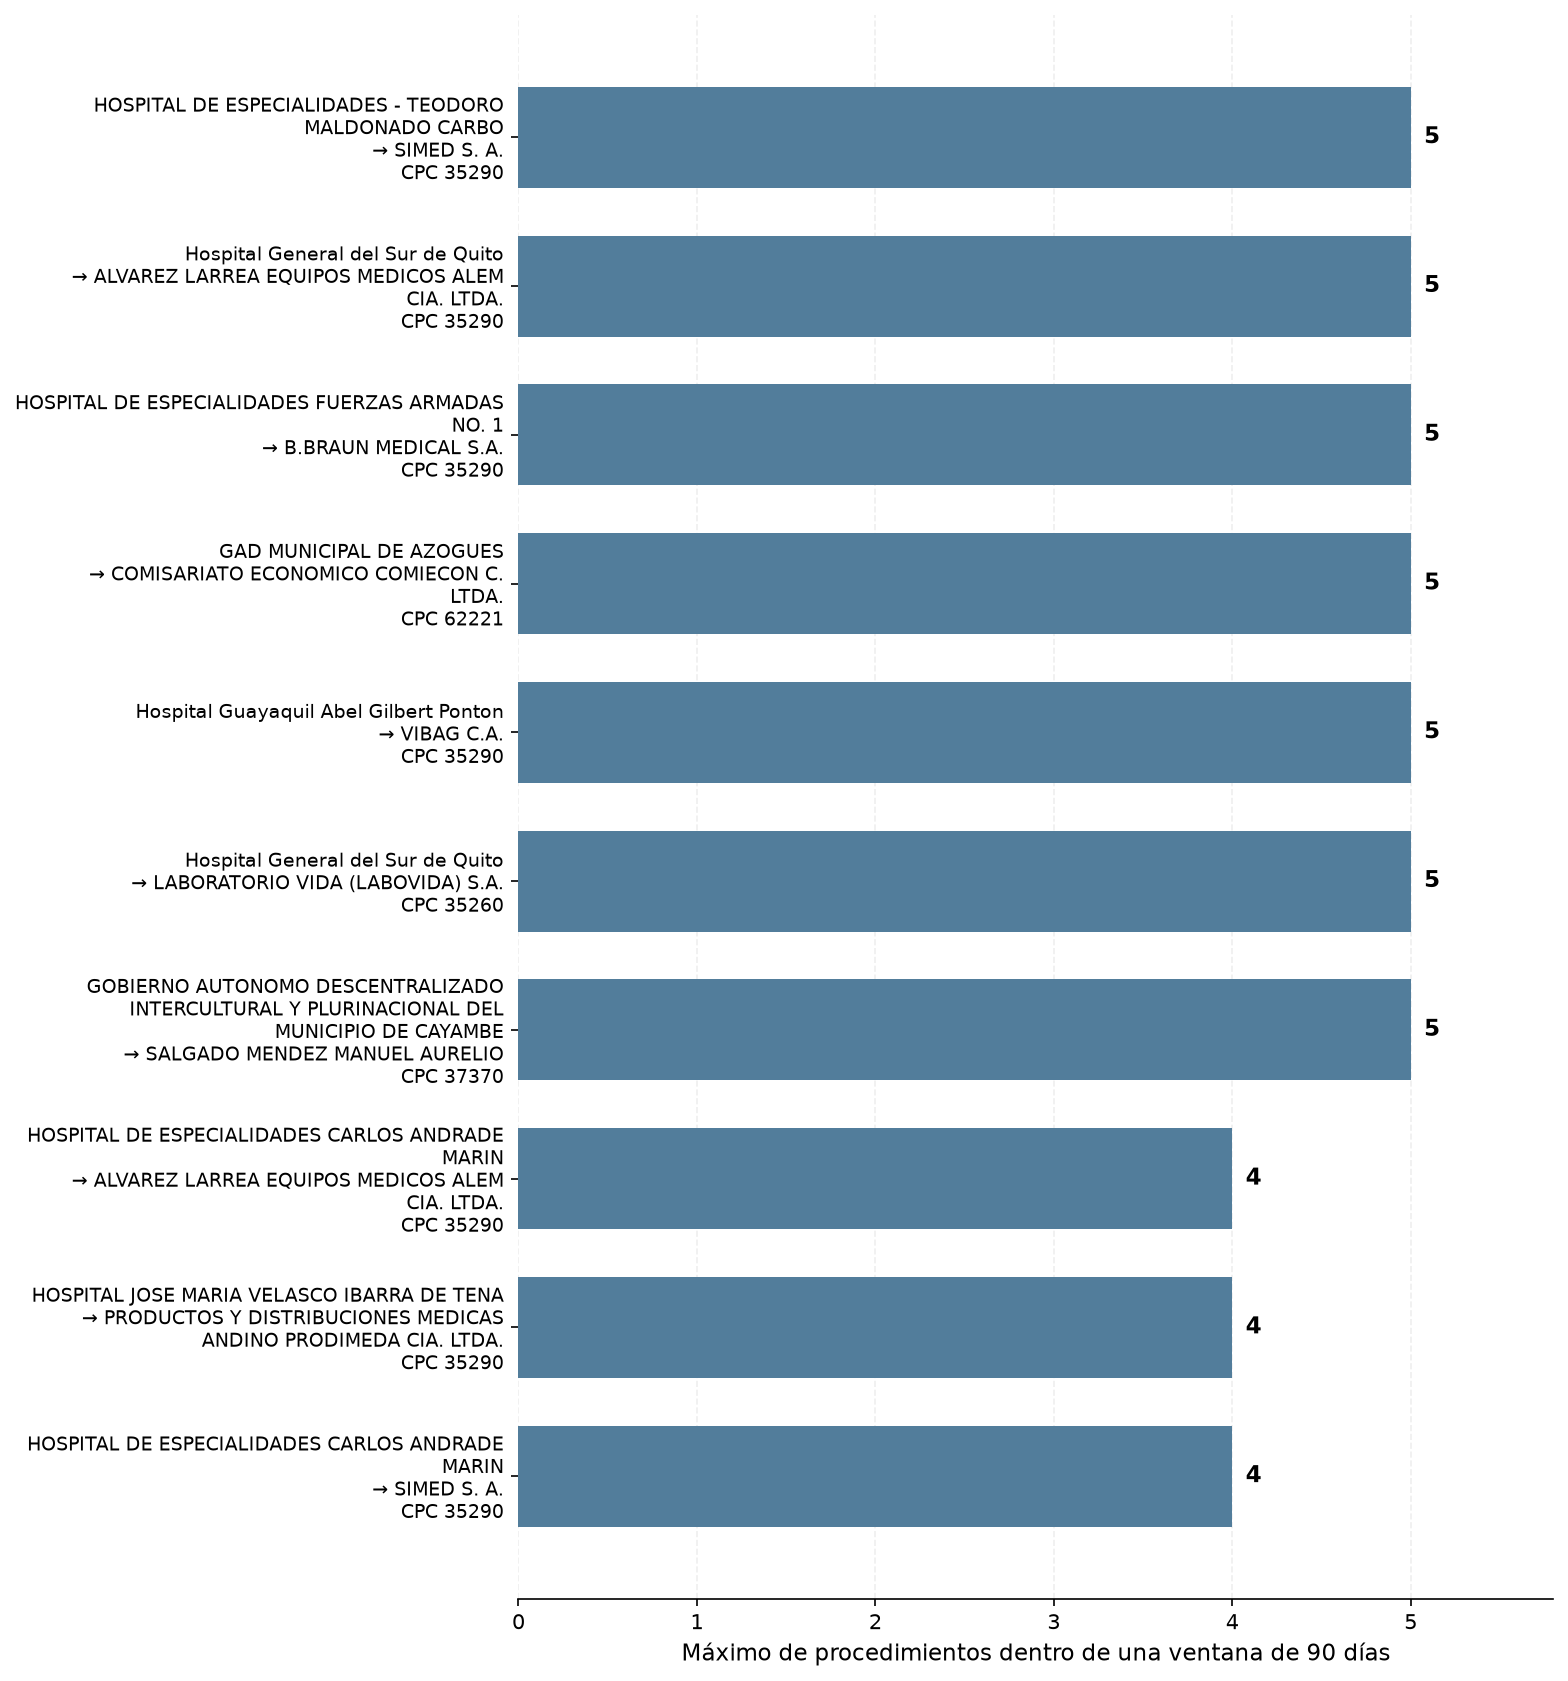

In [11]:
# ============================================================
# PASO 9. FIGURA 5
# RELACIONES RECURRENTES ENTRE ENTIDAD, PROVEEDOR Y CPC
# ============================================================
# Objetivo:
# Identificar relaciones recurrentes entre entidades contratantes
# y proveedores dentro de una misma categoría CPC a 5 dígitos.
#
# CRITERIO METODOLÓGICO SEGÚN OBSERVACIÓN DEL PROFESOR:
#
# Una relación se considera recurrente cuando una misma
# combinación de:
#
#   entidad contratante + proveedor + CPC a 5 dígitos
#
# registra MÁS DE 3 procedimientos distintos dentro de
# cualquier ventana móvil de 90 días.
#
# Adicionalmente:
# - Se excluye Catálogo Electrónico si existieran registros
#   correspondientes a esa modalidad.
# - Se utiliza el OCID para contar procedimientos distintos.
# - Se conserva el inicio y fin de la ventana de máxima
#   recurrencia para documentar temporalmente el patrón.
#
# IMPORTANTE:
# - Recurrencia NO equivale a riesgo.
# - Recurrencia NO demuestra concentración.
# - Recurrencia NO constituye evidencia de irregularidad.
# - El CPC a 5 dígitos funciona como aproximación homogénea
#   al tipo de bien o servicio contratado.
# ============================================================


import os
import textwrap
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 1. PREPARAR BASE DE ADJUDICACIONES
# ============================================================

base_recurrencia = adjudicaciones_df[
    [
        "ocid",
        "buyer_id",
        "supplier_id",
        "nombre_proveedor_limpio",
        "cpc_5",
        "cpc_description",
        "award_date_local"
    ]
].copy()


# ------------------------------------------------------------
# Convertir fecha de adjudicación
# ------------------------------------------------------------

base_recurrencia["fecha_adjudicacion"] = pd.to_datetime(
    base_recurrencia["award_date_local"],
    errors="coerce"
)


# ============================================================
# 2. VALIDAR EXCLUSIÓN DE CATÁLOGO ELECTRÓNICO
# ============================================================
# El universo del proyecto corresponde a Subasta Inversa
# Electrónica. No obstante, se incluye una validación explícita
# para documentar que Catálogo Electrónico no forme parte del
# análisis de recurrencia.
#
# El bloque busca automáticamente una variable de tipo/modalidad
# de procedimiento si está disponible en procedimientos_df.
# ============================================================

columnas_tipo_posibles = [
    "tipo_procedimiento",
    "procedure_type",
    "procurement_method_details",
    "tender_procurement_method_details",
    "tender_method_details",
    "modalidad"
]


columna_tipo = next(
    (
        columna
        for columna in columnas_tipo_posibles
        if columna in procedimientos_df.columns
    ),
    None
)


if columna_tipo is not None:

    tipo_procedimiento_df = (
        procedimientos_df[
            [
                "ocid",
                columna_tipo
            ]
        ]
        .drop_duplicates(
            subset=["ocid"]
        )
        .copy()
    )


    base_recurrencia = base_recurrencia.merge(
        tipo_procedimiento_df,
        on="ocid",
        how="left"
    )


    mascara_catalogo = (
        base_recurrencia[
            columna_tipo
        ]
        .astype("string")
        .str.upper()
        .str.contains(
            "CATALOGO|CATÁLOGO",
            na=False
        )
    )


    registros_catalogo = int(
        mascara_catalogo.sum()
    )


    print(
        f"Registros identificados como Catálogo Electrónico: "
        f"{registros_catalogo:,}"
    )


    base_recurrencia = (
        base_recurrencia[
            ~mascara_catalogo
        ]
        .copy()
    )


else:

    print(
        "No se encontró una columna específica de modalidad "
        "en procedimientos_df."
    )

    print(
        "El universo cargado corresponde a Subasta Inversa "
        "Electrónica 2025; no se aplicó un filtro adicional "
        "de Catálogo Electrónico."
    )


# ============================================================
# 3. CONTROL DE VARIABLES INDISPENSABLES
# ============================================================

total_inicial_recurrencia = len(
    base_recurrencia
)


faltantes_recurrencia = (
    base_recurrencia[
        [
            "ocid",
            "buyer_id",
            "supplier_id",
            "cpc_5",
            "fecha_adjudicacion"
        ]
    ]
    .isna()
    .any(axis=1)
    .sum()
)


print("\n" + "=" * 70)
print("CONTROL DEL ANÁLISIS DE RECURRENCIA")
print("=" * 70)

print(
    f"\nRegistros antes de eliminar faltantes: "
    f"{total_inicial_recurrencia:,}"
)

print(
    f"Registros con variables indispensables faltantes: "
    f"{faltantes_recurrencia:,}"
)


# ------------------------------------------------------------
# Mantener únicamente registros completos
# ------------------------------------------------------------

base_recurrencia = (
    base_recurrencia
    .dropna(
        subset=[
            "ocid",
            "buyer_id",
            "supplier_id",
            "cpc_5",
            "fecha_adjudicacion"
        ]
    )
    .copy()
)


# ============================================================
# 4. EVITAR DOBLE CONTEO DEL MISMO PROCEDIMIENTO
# ============================================================
# Una misma combinación comprador-proveedor-CPC-OCID se cuenta
# una sola vez.
# ============================================================

base_recurrencia = (
    base_recurrencia
    .drop_duplicates(
        subset=[
            "buyer_id",
            "supplier_id",
            "cpc_5",
            "ocid"
        ]
    )
    .copy()
)


print(
    f"Registros válidos después de depuración: "
    f"{len(base_recurrencia):,}"
)


# ============================================================
# 5. INCORPORAR NOMBRE REPRESENTATIVO DEL COMPRADOR
# ============================================================

def nombre_representativo_recurrencia(serie):

    serie = serie.dropna()

    if len(serie) == 0:
        return None

    moda = serie.mode()

    if len(moda) > 0:
        return moda.iloc[0]

    return serie.iloc[0]


nombres_compradores = (
    procedimientos_df
    .groupby(
        "buyer_id",
        as_index=False
    )
    .agg(
        buyer_name=(
            "buyer_name",
            nombre_representativo_recurrencia
        )
    )
)


base_recurrencia = (
    base_recurrencia
    .merge(
        nombres_compradores,
        on="buyer_id",
        how="left"
    )
)


# ============================================================
# 6. CALCULAR MÁXIMA RECURRENCIA EN VENTANA DE 90 DÍAS
# ============================================================
# Para cada combinación:
#
# comprador + proveedor + CPC5
#
# se busca el máximo número de procedimientos distintos
# observados dentro de cualquier ventana móvil de 90 días.
#
# También se almacena:
# - fecha inicial de la ventana
# - fecha final de la ventana
# - duración observada
# ============================================================

resultados_recurrencia = []


for claves, grupo in base_recurrencia.groupby(
    [
        "buyer_id",
        "supplier_id",
        "cpc_5"
    ]
):

    buyer_id, supplier_id, cpc_5 = claves


    grupo = (
        grupo
        .sort_values(
            "fecha_adjudicacion"
        )
        .reset_index(
            drop=True
        )
    )


    fechas = (
        grupo[
            "fecha_adjudicacion"
        ]
        .tolist()
    )


    inicio = 0

    max_procesos_90d = 0

    fecha_inicio_max = None
    fecha_fin_max = None


    # --------------------------------------------------------
    # Ventana móvil
    # --------------------------------------------------------

    for fin in range(
        len(fechas)
    ):

        while (
            fechas[fin]
            - fechas[inicio]
            > pd.Timedelta(
                days=90
            )
        ):

            inicio += 1


        procesos_ventana = (
            fin
            - inicio
            + 1
        )


        if (
            procesos_ventana
            > max_procesos_90d
        ):

            max_procesos_90d = (
                procesos_ventana
            )

            fecha_inicio_max = (
                fechas[inicio]
            )

            fecha_fin_max = (
                fechas[fin]
            )


    # --------------------------------------------------------
    # Nombre del proveedor
    # --------------------------------------------------------

    nombre_proveedor = (
        nombre_representativo_recurrencia(
            grupo[
                "nombre_proveedor_limpio"
            ]
        )
    )


    if pd.isna(
        nombre_proveedor
    ):

        nombre_proveedor = (
            supplier_id
        )


    # --------------------------------------------------------
    # Nombre del comprador
    # --------------------------------------------------------

    nombre_comprador = (
        nombre_representativo_recurrencia(
            grupo[
                "buyer_name"
            ]
        )
    )


    if pd.isna(
        nombre_comprador
    ):

        nombre_comprador = (
            buyer_id
        )


    # --------------------------------------------------------
    # Descripción CPC
    # --------------------------------------------------------

    descripcion_cpc = (
        nombre_representativo_recurrencia(
            grupo[
                "cpc_description"
            ]
        )
    )


    if pd.isna(
        descripcion_cpc
    ):

        descripcion_cpc = (
            "Sin descripción"
        )


    # --------------------------------------------------------
    # Duración real de la ventana observada
    # --------------------------------------------------------

    if (
        fecha_inicio_max is not None
        and fecha_fin_max is not None
    ):

        duracion_ventana_dias = (
            fecha_fin_max
            - fecha_inicio_max
        ).days

    else:

        duracion_ventana_dias = None


    # --------------------------------------------------------
    # Guardar resultado
    # --------------------------------------------------------

    resultados_recurrencia.append(
        {
            "buyer_id":
                buyer_id,

            "supplier_id":
                supplier_id,

            "cpc_5":
                cpc_5,

            "buyer_name":
                nombre_comprador,

            "nombre_proveedor":
                nombre_proveedor,

            "cpc_description":
                descripcion_cpc,

            "numero_procesos_total":
                grupo[
                    "ocid"
                ].nunique(),

            "max_procesos_90d":
                max_procesos_90d,

            "fecha_inicio_ventana":
                fecha_inicio_max,

            "fecha_fin_ventana":
                fecha_fin_max,

            "duracion_ventana_dias":
                duracion_ventana_dias
        }
    )


# ------------------------------------------------------------
# Convertir resultados a DataFrame
# ------------------------------------------------------------

recurrencia_df = pd.DataFrame(
    resultados_recurrencia
)


# ============================================================
# 7. APLICAR CRITERIO DE RECURRENCIA
# ============================================================
# Más de 3 procedimientos distintos dentro de 90 días.
# Es decir:
#
# 4 o más procedimientos dentro de la ventana.
# ============================================================

relaciones_recurrentes = (
    recurrencia_df[
        recurrencia_df[
            "max_procesos_90d"
        ] > 3
    ]
    .sort_values(
        [
            "max_procesos_90d",
            "numero_procesos_total",
            "buyer_name",
            "nombre_proveedor"
        ],
        ascending=[
            False,
            False,
            True,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 8. MOSTRAR CONTROLES
# ============================================================

print(
    f"\nCombinaciones comprador-proveedor-CPC analizadas: "
    f"{len(recurrencia_df):,}"
)


print(
    f"Relaciones recurrentes identificadas: "
    f"{len(relaciones_recurrentes):,}"
)


# ============================================================
# 9. TABLA DE DISTRIBUCIÓN DE RECURRENCIA
# ============================================================

tabla_distribucion_recurrencia = (
    relaciones_recurrentes[
        "max_procesos_90d"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "Máximo de procedimientos en 90 días"
    )
    .reset_index(
        name="Número de relaciones"
    )
)


print(
    "\nDISTRIBUCIÓN DE RELACIONES RECURRENTES\n"
)


display(
    tabla_distribucion_recurrencia
)


# ============================================================
# 10. TABLA DE RELACIONES RECURRENTES
# ============================================================

tabla_relaciones_recurrentes = (
    relaciones_recurrentes[
        [
            "buyer_name",
            "nombre_proveedor",
            "cpc_5",
            "cpc_description",
            "numero_procesos_total",
            "max_procesos_90d",
            "fecha_inicio_ventana",
            "fecha_fin_ventana",
            "duracion_ventana_dias"
        ]
    ]
    .rename(
        columns={
            "buyer_name":
                "Entidad contratante",

            "nombre_proveedor":
                "Proveedor",

            "cpc_5":
                "CPC 5 dígitos",

            "cpc_description":
                "Descripción CPC",

            "numero_procesos_total":
                "Procesos totales",

            "max_procesos_90d":
                "Máximo en 90 días",

            "fecha_inicio_ventana":
                "Inicio ventana",

            "fecha_fin_ventana":
                "Fin ventana",

            "duracion_ventana_dias":
                "Duración observada (días)"
        }
    )
)


print(
    "\nRELACIONES RECURRENTES IDENTIFICADAS\n"
)


display(
    tabla_relaciones_recurrentes
)


# ============================================================
# 11. SELECCIONAR TOP 10
# ============================================================

top_recurrencia = (
    relaciones_recurrentes
    .head(10)
    .copy()
)


# ============================================================
# 12. AJUSTAR NOMBRES COMPLETOS
# ============================================================

def dividir_texto(
    texto,
    ancho=40
):

    if pd.isna(
        texto
    ):

        return (
            "No informado"
        )


    return (
        textwrap.fill(
            str(texto),
            width=ancho,
            break_long_words=False,
            break_on_hyphens=False
        )
    )


# ------------------------------------------------------------
# Crear etiqueta:
#
# Entidad
# → Proveedor
# CPC
# ------------------------------------------------------------

top_recurrencia[
    "etiqueta"
] = (
    top_recurrencia
    .apply(
        lambda fila:

        f"{dividir_texto(fila['buyer_name'], 42)}\n"
        f"→ {dividir_texto(fila['nombre_proveedor'], 38)}\n"
        f"CPC {fila['cpc_5']}",

        axis=1
    )
)


# ============================================================
# 13. ORDEN PARA GRÁFICO HORIZONTAL
# ============================================================

top_recurrencia_grafico = (
    top_recurrencia
    .sort_values(
        [
            "max_procesos_90d",
            "numero_procesos_total"
        ],
        ascending=[
            True,
            True
        ]
    )
    .copy()
)


# ============================================================
# 14. CREAR FIGURA 5
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 12),
    dpi=150
)


barras = ax.barh(
    top_recurrencia_grafico[
        "etiqueta"
    ],
    top_recurrencia_grafico[
        "max_procesos_90d"
    ],
    color="#527D9B",
    height=0.68
)


# ============================================================
# 15. VALORES AL FINAL DE LAS BARRAS
# ============================================================

max_recurrencia = (
    top_recurrencia_grafico[
        "max_procesos_90d"
    ]
    .max()
)


for barra, valor in zip(

    barras,

    top_recurrencia_grafico[
        "max_procesos_90d"
    ]
):

    ax.text(
        valor
        + max_recurrencia * 0.015,

        barra.get_y()
        + barra.get_height() / 2,

        f"{int(valor)}",

        va="center",
        ha="left",

        fontsize=11,
        fontweight="bold"
    )


# ============================================================
# 16. FORMATO DE EJES
# ============================================================

ax.set_xlabel(
    "Máximo de procedimientos dentro de una ventana de 90 días",
    fontsize=11
)

ax.set_ylabel("")


ax.set_xlim(
    0,
    max_recurrencia + 0.8
)


ax.set_xticks(
    range(
        0,
        int(
            max_recurrencia
        ) + 1
    )
)


# ============================================================
# 17. ESTILO VISUAL
# ============================================================

ax.xaxis.grid(
    True,
    linestyle="--",
    alpha=0.20
)

ax.set_axisbelow(True)


ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)

ax.spines[
    "left"
].set_visible(False)


ax.tick_params(
    axis="y",
    labelsize=9
)

ax.tick_params(
    axis="x",
    labelsize=10
)


# ------------------------------------------------------------
# Espacio para nombres completos
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.48,
    right=0.94,
    top=0.97,
    bottom=0.09
)


# ============================================================
# 18. GUARDAR FIGURA 5
# ============================================================

ruta_figura_5 = os.path.join(
    ruta_figuras,
    "figura_5_relaciones_recurrentes_90_dias_2025.png"
)


fig.savefig(
    ruta_figura_5,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


print(
    "\nFigura 5 guardada en:"
)

print(
    ruta_figura_5
)


plt.show()

CONTROL DEL ANÁLISIS DE CONCENTRACIÓN

Registros iniciales: 15,718

No se encontró una columna específica de modalidad en procedimientos_df.
El universo cargado corresponde a Subasta Inversa Electrónica 2025; no se aplicó un filtro adicional de Catálogo Electrónico.

Registros con monto >= USD 5.000: 15,665

Entidades con al menos 5 adjudicaciones: 687

Entidades elegibles con un solo proveedor (HHI* no definido): 0
Entidades representadas en la Figura 6: 687

Mediana HHI* por frecuencia: 0.004
Mediana HHI* monetario: 0.086

ENTIDADES CON MAYOR DIFERENCIA ENTRE CONCENTRACIÓN MONETARIA Y POR FRECUENCIA



,Entidad contratante,Adjudicaciones,Proveedores,HHI* frecuencia,HHI* monetario,Diferencia HHI*,CR4 frecuencia,CR4 monetario,Entropía frecuencia,Entropía monetaria
0,MINISTERIO DE PRODUCCION COMERCIO EXTERIOR INV...,6,5,0.028,0.895,0.867,0.833,0.994,0.970,0.146
1,GOBIERNO AUTONOMO DESCENTRALIZADO MUNICIPAL DE...,12,12,0.000,0.845,0.845,0.333,0.973,1.000,0.167
2,Escuela Superior Politecnica Agropecuaria de M...,12,12,0.000,0.770,0.770,0.333,0.944,1.000,0.242
3,ESTACION NAVAL DE QUITO,7,6,0.020,0.754,0.733,0.714,0.976,0.976,0.284
4,DIRECCION DISTRITAL08D04,5,3,0.160,0.885,0.725,1.000,1.000,0.865,0.174
5,EMPRESA PUBLICA METROPOLITANA MERCADO MAYORIST...,5,5,0.000,0.674,0.674,0.800,0.981,1.000,0.373
6,HOSPITAL GENERAL MONTE SINAI,5,5,0.000,0.673,0.673,0.800,0.994,1.000,0.342
7,GOBIERNO AUTONOMO DESCENTRALIZADO MUNICIPAL IN...,5,5,0.000,0.665,0.665,0.800,0.991,1.000,0.364
8,Municipio El Chaco,7,7,0.000,0.658,0.658,0.571,0.949,1.000,0.370
9,HOSPITAL GENERAL MARCO VINICIO IZA,5,5,0.000,0.646,0.646,0.800,0.979,1.000,0.396



Figura 6 guardada en:
../reports/figures/figura_6_hhi_normalizado_monetario_frecuencia_2025.png


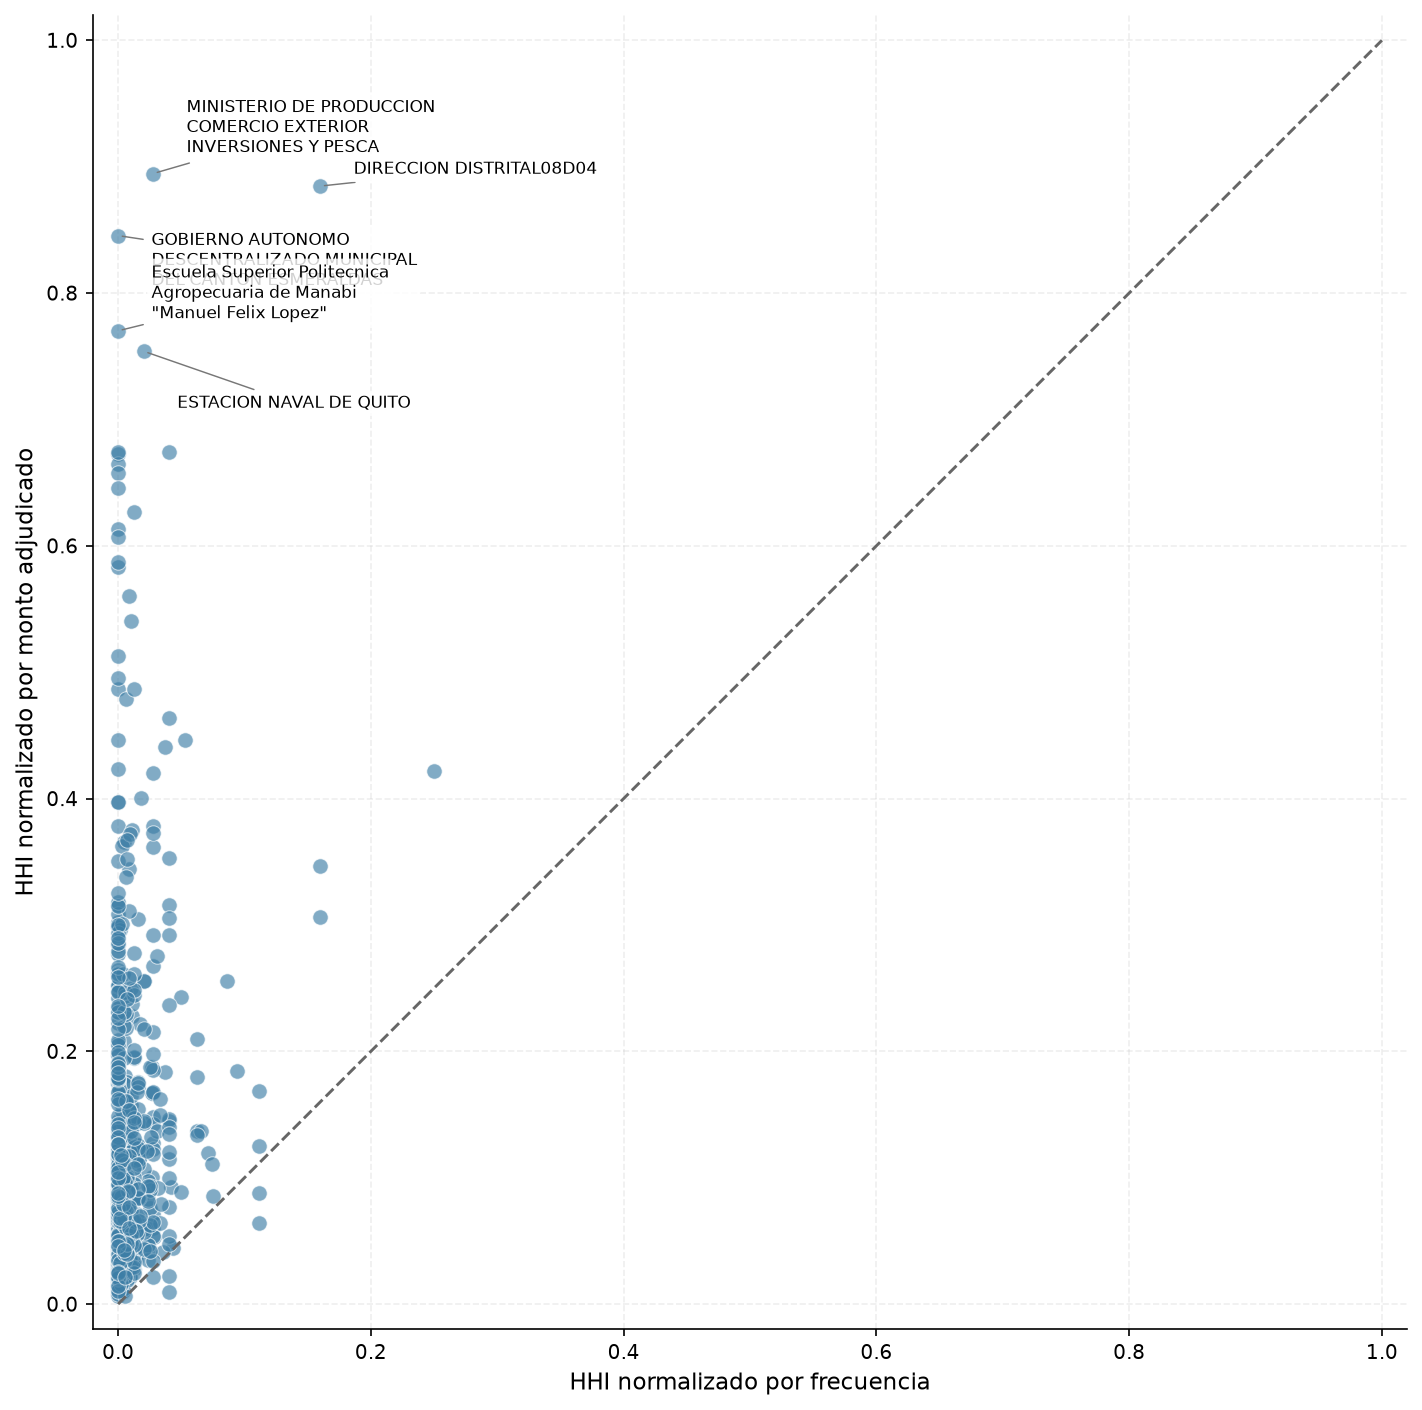

In [12]:
# ============================================================
# PASO 10. FIGURA 6
# CONCENTRACIÓN MONETARIA VS. CONCENTRACIÓN POR FRECUENCIA
# ============================================================
#
# Objetivo:
# Comparar dos dimensiones diferentes de concentración
# para cada entidad contratante:
#
# 1. HHI normalizado por frecuencia:
#    mide qué tan concentrado está el número de adjudicaciones
#    entre los proveedores de una entidad.
#
# 2. HHI normalizado monetario:
#    mide qué tan concentrado está el valor económico adjudicado
#    entre los proveedores de una entidad.
#
# CORRECCIONES METODOLÓGICAS:
#
# - Se excluye Catálogo Electrónico si existieran registros.
# - Se consideran adjudicaciones de USD 5.000 o más.
# - Solo se calcula concentración para compradores con
#   al menos 5 adjudicaciones.
# - El HHI monetario y el HHI por frecuencia se calculan
#   y reportan por separado.
# - Se utiliza HHI normalizado:
#
#       HHI* = (HHI - 1/n) / (1 - 1/n)
#
#   donde n es el número de proveedores.
#
# - Para n = 1, HHI* NO está definido.
# - Se calculan adicionalmente CR4 y entropía normalizada
#   como métricas complementarias.
#
# IMPORTANTE:
# - Un HHI alto NO constituye evidencia de colusión,
#   riesgo o irregularidad.
# - Las métricas deben interpretarse considerando el objeto
#   contractual, la estructura del mercado y sus proveedores.
# ============================================================


import os
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 1. CREAR BASE PARA EL ANÁLISIS DE CONCENTRACIÓN
# ============================================================

base_concentracion = adjudicaciones_df[
    [
        "ocid",
        "buyer_id",
        "supplier_id",
        "award_amount"
    ]
].copy()


# ------------------------------------------------------------
# Convertir monto a numérico
# ------------------------------------------------------------

base_concentracion["award_amount"] = pd.to_numeric(
    base_concentracion["award_amount"],
    errors="coerce"
)


print("=" * 75)
print("CONTROL DEL ANÁLISIS DE CONCENTRACIÓN")
print("=" * 75)

print(
    f"\nRegistros iniciales: "
    f"{len(base_concentracion):,}"
)


# ============================================================
# 2. VALIDAR Y EXCLUIR CATÁLOGO ELECTRÓNICO
# ============================================================
# El universo principal corresponde a Subasta Inversa
# Electrónica; no obstante, se realiza una validación explícita
# para evitar que registros de Catálogo Electrónico generen
# recurrencia o concentración artificial.
# ============================================================

columnas_modalidad_posibles = [
    "tipo_procedimiento",
    "procedure_type",
    "procurement_method_details",
    "tender_procurement_method_details",
    "tender_method_details",
    "modalidad"
]


columna_modalidad = next(
    (
        columna
        for columna in columnas_modalidad_posibles
        if columna in procedimientos_df.columns
    ),
    None
)


if columna_modalidad is not None:

    modalidad_df = (
        procedimientos_df[
            [
                "ocid",
                columna_modalidad
            ]
        ]
        .drop_duplicates(
            subset=["ocid"]
        )
        .copy()
    )


    base_concentracion = (
        base_concentracion
        .merge(
            modalidad_df,
            on="ocid",
            how="left"
        )
    )


    mascara_catalogo = (
        base_concentracion[
            columna_modalidad
        ]
        .astype("string")
        .str.upper()
        .str.contains(
            r"CAT[ÁA]LOGO",
            regex=True,
            na=False
        )
    )


    registros_catalogo = int(
        mascara_catalogo.sum()
    )


    print(
        f"\nRegistros identificados como Catálogo Electrónico: "
        f"{registros_catalogo:,}"
    )


    base_concentracion = (
        base_concentracion[
            ~mascara_catalogo
        ]
        .copy()
    )


else:

    print(
        "\nNo se encontró una columna específica de modalidad "
        "en procedimientos_df."
    )

    print(
        "El universo cargado corresponde a Subasta Inversa "
        "Electrónica 2025; no se aplicó un filtro adicional "
        "de Catálogo Electrónico."
    )


# ============================================================
# 3. FILTRO ANALÍTICO DE USD 5.000
# ============================================================
# Se excluyen adjudicaciones inferiores a USD 5.000 para este
# análisis específico de concentración, conforme a la
# observación metodológica del profesor.
# ============================================================

base_concentracion = base_concentracion[
    base_concentracion["ocid"].notna()
    & base_concentracion["buyer_id"].notna()
    & base_concentracion["supplier_id"].notna()
    & base_concentracion["award_amount"].notna()
    & (base_concentracion["award_amount"] >= 5000)
].copy()


print(
    f"\nRegistros con monto >= USD 5.000: "
    f"{len(base_concentracion):,}"
)


# ============================================================
# 4. ELIMINAR DUPLICADOS EXACTOS
# ============================================================
# Se eliminan únicamente registros exactamente repetidos.
#
# No se elimina automáticamente una segunda adjudicación del
# mismo proveedor dentro del mismo OCID si presenta un monto
# diferente.
# ============================================================

base_concentracion = (
    base_concentracion
    .drop_duplicates(
        subset=[
            "ocid",
            "buyer_id",
            "supplier_id",
            "award_amount"
        ]
    )
    .copy()
)


# ============================================================
# 5. CONSOLIDAR MONTO POR PROCEDIMIENTO Y PROVEEDOR
# ============================================================
# Esto permite:
#
# - contar una sola vez el procedimiento para frecuencia;
# - conservar el monto total asociado al proveedor dentro
#   de ese procedimiento.
# ============================================================

procedimiento_proveedor = (
    base_concentracion
    .groupby(
        [
            "ocid",
            "buyer_id",
            "supplier_id"
        ],
        as_index=False
    )
    .agg(
        monto_procedimiento=(
            "award_amount",
            "sum"
        )
    )
)


# ============================================================
# 6. IDENTIFICAR COMPRADORES CON >= 5 ADJUDICACIONES
# ============================================================

resumen_entidades = (
    procedimiento_proveedor
    .groupby(
        "buyer_id",
        as_index=False
    )
    .agg(
        numero_adjudicaciones=(
            "ocid",
            "nunique"
        ),

        numero_proveedores=(
            "supplier_id",
            "nunique"
        )
    )
)


entidades_elegibles = (
    resumen_entidades[
        resumen_entidades[
            "numero_adjudicaciones"
        ] >= 5
    ]
    .copy()
)


print(
    f"\nEntidades con al menos 5 adjudicaciones: "
    f"{len(entidades_elegibles):,}"
)


# ------------------------------------------------------------
# Mantener únicamente compradores elegibles
# ------------------------------------------------------------

procedimiento_proveedor = (
    procedimiento_proveedor[
        procedimiento_proveedor[
            "buyer_id"
        ].isin(
            entidades_elegibles[
                "buyer_id"
            ]
        )
    ]
    .copy()
)


# ============================================================
# 7. CONSOLIDAR RELACIÓN COMPRADOR-PROVEEDOR
# ============================================================

relacion_concentracion = (
    procedimiento_proveedor
    .groupby(
        [
            "buyer_id",
            "supplier_id"
        ],
        as_index=False
    )
    .agg(
        frecuencia=(
            "ocid",
            "nunique"
        ),

        monto_total=(
            "monto_procedimiento",
            "sum"
        )
    )
)


# ============================================================
# 8. CALCULAR TOTALES POR ENTIDAD
# ============================================================

totales_entidad = (
    relacion_concentracion
    .groupby(
        "buyer_id",
        as_index=False
    )
    .agg(
        total_adjudicaciones=(
            "frecuencia",
            "sum"
        ),

        total_monto=(
            "monto_total",
            "sum"
        ),

        numero_proveedores=(
            "supplier_id",
            "nunique"
        )
    )
)


relacion_concentracion = (
    relacion_concentracion
    .merge(
        totales_entidad,
        on="buyer_id",
        how="left"
    )
)


# ============================================================
# 9. PARTICIPACIONES POR FRECUENCIA Y MONTO
# ============================================================

relacion_concentracion[
    "participacion_frecuencia"
] = (
    relacion_concentracion[
        "frecuencia"
    ]
    /
    relacion_concentracion[
        "total_adjudicaciones"
    ]
)


relacion_concentracion[
    "participacion_monetaria"
] = (
    relacion_concentracion[
        "monto_total"
    ]
    /
    relacion_concentracion[
        "total_monto"
    ]
)


# ============================================================
# 10. COMPONENTES DEL HHI
# ============================================================

relacion_concentracion[
    "hhi_comp_frecuencia"
] = (
    relacion_concentracion[
        "participacion_frecuencia"
    ] ** 2
)


relacion_concentracion[
    "hhi_comp_monetario"
] = (
    relacion_concentracion[
        "participacion_monetaria"
    ] ** 2
)


# ============================================================
# 11. CALCULAR HHI SIN NORMALIZAR POR ENTIDAD
# ============================================================

hhi_entidad = (
    relacion_concentracion
    .groupby(
        "buyer_id",
        as_index=False
    )
    .agg(
        hhi_frecuencia=(
            "hhi_comp_frecuencia",
            "sum"
        ),

        hhi_monetario=(
            "hhi_comp_monetario",
            "sum"
        ),

        numero_proveedores=(
            "supplier_id",
            "nunique"
        ),

        numero_adjudicaciones=(
            "frecuencia",
            "sum"
        ),

        monto_total_adjudicado=(
            "monto_total",
            "sum"
        )
    )
)


# ============================================================
# 12. NORMALIZAR HHI
# ============================================================
#
# HHI* = (HHI - 1/n) / (1 - 1/n)
#
# n = número de proveedores.
#
# Si n = 1:
# HHI* NO está definido.
# ============================================================

def normalizar_hhi(
    hhi,
    n
):

    if n <= 1:
        return np.nan


    hhi_normalizado = (
        (
            hhi
            - (1 / n)
        )
        /
        (
            1
            - (1 / n)
        )
    )


    # Control por precisión numérica.
    return float(
        np.clip(
            hhi_normalizado,
            0,
            1
        )
    )


hhi_entidad[
    "hhi_frecuencia_normalizado"
] = (
    hhi_entidad.apply(
        lambda fila:
        normalizar_hhi(
            fila[
                "hhi_frecuencia"
            ],
            fila[
                "numero_proveedores"
            ]
        ),
        axis=1
    )
)


hhi_entidad[
    "hhi_monetario_normalizado"
] = (
    hhi_entidad.apply(
        lambda fila:
        normalizar_hhi(
            fila[
                "hhi_monetario"
            ],
            fila[
                "numero_proveedores"
            ]
        ),
        axis=1
    )
)


# ============================================================
# 13. CALCULAR CR4
# ============================================================
# CR4:
# participación acumulada de los cuatro proveedores principales.
#
# Se calcula por separado para:
#
# - frecuencia
# - monto
# ============================================================

def calcular_cr4(grupo):

    cr4_frecuencia = (
        grupo[
            "participacion_frecuencia"
        ]
        .nlargest(4)
        .sum()
    )


    cr4_monetario = (
        grupo[
            "participacion_monetaria"
        ]
        .nlargest(4)
        .sum()
    )


    return pd.Series(
        {
            "cr4_frecuencia":
                cr4_frecuencia,

            "cr4_monetario":
                cr4_monetario
        }
    )


cr4_entidad = (
    relacion_concentracion
    .groupby(
        "buyer_id"
    )
    .apply(
        calcular_cr4,
        include_groups=False
    )
    .reset_index()
)


# ============================================================
# 14. CALCULAR ENTROPÍA NORMALIZADA
# ============================================================
# Entropía normalizada:
#
# H = -SUM(p * ln(p)) / ln(n)
#
# Valores cercanos a 1:
# mayor diversidad en la distribución.
#
# Valores cercanos a 0:
# menor diversidad.
#
# Para n = 1 no está definida.
# ============================================================

def entropia_normalizada(
    participaciones
):

    participaciones = (
        np.asarray(
            participaciones,
            dtype=float
        )
    )


    participaciones = (
        participaciones[
            participaciones > 0
        ]
    )


    n = len(
        participaciones
    )


    if n <= 1:
        return np.nan


    entropia = (
        -np.sum(
            participaciones
            * np.log(
                participaciones
            )
        )
    )


    return float(
        entropia
        / np.log(n)
    )


entropia_entidad = (
    relacion_concentracion
    .groupby(
        "buyer_id"
    )
    .apply(
        lambda grupo:
        pd.Series(
            {
                "entropia_frecuencia":
                    entropia_normalizada(
                        grupo[
                            "participacion_frecuencia"
                        ]
                    ),

                "entropia_monetaria":
                    entropia_normalizada(
                        grupo[
                            "participacion_monetaria"
                        ]
                    )
            }
        ),
        include_groups=False
    )
    .reset_index()
)


# ============================================================
# 15. INCORPORAR CR4 Y ENTROPÍA
# ============================================================

hhi_entidad = (
    hhi_entidad
    .merge(
        cr4_entidad,
        on="buyer_id",
        how="left"
    )
    .merge(
        entropia_entidad,
        on="buyer_id",
        how="left"
    )
)


# ============================================================
# 16. INCORPORAR NOMBRE DE LA ENTIDAD
# ============================================================

def nombre_representativo_concentracion(
    serie
):

    serie = (
        serie
        .dropna()
    )


    if len(serie) == 0:
        return None


    moda = (
        serie.mode()
    )


    if len(moda) > 0:
        return moda.iloc[0]


    return serie.iloc[0]


nombres_entidades = (
    procedimientos_df
    .groupby(
        "buyer_id",
        as_index=False
    )
    .agg(
        buyer_name=(
            "buyer_name",
            nombre_representativo_concentracion
        )
    )
)


hhi_entidad = (
    hhi_entidad
    .merge(
        nombres_entidades,
        on="buyer_id",
        how="left"
    )
)


# ============================================================
# 17. IDENTIFICAR CASOS CON UN SOLO PROVEEDOR
# ============================================================

casos_un_proveedor = (
    hhi_entidad[
        hhi_entidad[
            "numero_proveedores"
        ] == 1
    ]
    .copy()
)


print(
    f"\nEntidades elegibles con un solo proveedor "
    f"(HHI* no definido): "
    f"{len(casos_un_proveedor):,}"
)


# ============================================================
# 18. CREAR BASE FINAL PARA FIGURA 6
# ============================================================

hhi_figura = (
    hhi_entidad
    .dropna(
        subset=[
            "hhi_frecuencia_normalizado",
            "hhi_monetario_normalizado"
        ]
    )
    .copy()
)


print(
    f"Entidades representadas en la Figura 6: "
    f"{len(hhi_figura):,}"
)


# ============================================================
# 19. RESUMEN DE HHI NORMALIZADO
# ============================================================

mediana_hhi_frecuencia = (
    hhi_figura[
        "hhi_frecuencia_normalizado"
    ]
    .median()
)


mediana_hhi_monetario = (
    hhi_figura[
        "hhi_monetario_normalizado"
    ]
    .median()
)


print(
    f"\nMediana HHI* por frecuencia: "
    f"{mediana_hhi_frecuencia:.3f}"
)

print(
    f"Mediana HHI* monetario: "
    f"{mediana_hhi_monetario:.3f}"
)


# ============================================================
# 20. DIFERENCIA ENTRE AMBOS HHI
# ============================================================
# Diferencia positiva:
#
# HHI monetario > HHI frecuencia.
#
# Diferencia negativa:
#
# HHI frecuencia > HHI monetario.
#
# La diferencia NO se interpreta automáticamente como riesgo.
# ============================================================

hhi_figura[
    "diferencia_hhi"
] = (
    hhi_figura[
        "hhi_monetario_normalizado"
    ]
    -
    hhi_figura[
        "hhi_frecuencia_normalizado"
    ]
)


hhi_figura[
    "diferencia_absoluta"
] = (
    hhi_figura[
        "diferencia_hhi"
    ]
    .abs()
)


# ============================================================
# 21. TOP 10 ENTIDADES CON MAYOR DIFERENCIA
# ============================================================

top_diferencias_tabla = (
    hhi_figura
    .sort_values(
        "diferencia_absoluta",
        ascending=False
    )
    .head(10)
    .copy()
)


tabla_figura_6 = (
    top_diferencias_tabla[
        [
            "buyer_name",
            "numero_adjudicaciones",
            "numero_proveedores",
            "hhi_frecuencia_normalizado",
            "hhi_monetario_normalizado",
            "diferencia_hhi",
            "cr4_frecuencia",
            "cr4_monetario",
            "entropia_frecuencia",
            "entropia_monetaria"
        ]
    ]
    .rename(
        columns={
            "buyer_name":
                "Entidad contratante",

            "numero_adjudicaciones":
                "Adjudicaciones",

            "numero_proveedores":
                "Proveedores",

            "hhi_frecuencia_normalizado":
                "HHI* frecuencia",

            "hhi_monetario_normalizado":
                "HHI* monetario",

            "diferencia_hhi":
                "Diferencia HHI*",

            "cr4_frecuencia":
                "CR4 frecuencia",

            "cr4_monetario":
                "CR4 monetario",

            "entropia_frecuencia":
                "Entropía frecuencia",

            "entropia_monetaria":
                "Entropía monetaria"
        }
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Redondear únicamente para presentación
# ------------------------------------------------------------

columnas_decimales = [
    "HHI* frecuencia",
    "HHI* monetario",
    "Diferencia HHI*",
    "CR4 frecuencia",
    "CR4 monetario",
    "Entropía frecuencia",
    "Entropía monetaria"
]


tabla_figura_6[
    columnas_decimales
] = (
    tabla_figura_6[
        columnas_decimales
    ]
    .round(3)
)


print(
    "\nENTIDADES CON MAYOR DIFERENCIA ENTRE "
    "CONCENTRACIÓN MONETARIA Y POR FRECUENCIA\n"
)


display(
    tabla_figura_6
)


# ============================================================
# 22. CREAR FIGURA 6
# ============================================================
# Cada punto representa una entidad contratante.
#
# Ambos ejes utilizan la misma escala 0-1 para permitir
# una comparación directa entre ambas dimensiones.
# ============================================================

fig, ax = plt.subplots(
    figsize=(10.5, 9.5),
    dpi=150
)


ax.scatter(
    hhi_figura[
        "hhi_frecuencia_normalizado"
    ],
    hhi_figura[
        "hhi_monetario_normalizado"
    ],
    s=55,
    alpha=0.65,
    color="#3D7EA6",
    edgecolor="white",
    linewidth=0.5
)


# ============================================================
# 23. LÍNEA DE IGUALDAD
# ============================================================
# Sobre la línea:
# concentración monetaria = concentración por frecuencia.
#
# Encima:
# concentración monetaria > frecuencia.
#
# Debajo:
# concentración por frecuencia > monetaria.
# ============================================================

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.4,
    color="#666666"
)


# ============================================================
# 24. ETIQUETAR LAS 5 MAYORES DIFERENCIAS
# ============================================================

top_5_diferencias = (
    hhi_figura
    .sort_values(
        "diferencia_absoluta",
        ascending=False
    )
    .head(5)
    .copy()
)


def dividir_nombre_figura_6(
    texto,
    ancho=28
):

    if pd.isna(texto):
        return "No informado"


    return "\n".join(
        textwrap.wrap(
            str(texto),
            width=ancho,
            break_long_words=False,
            break_on_hyphens=False
        )
    )


desplazamientos = [
    (16, 22),
    (16, -12),
    (16, 18),
    (16, -25),
    (16, 8)
]


for (
    (_, fila),
    desplazamiento
) in zip(
    top_5_diferencias.iterrows(),
    desplazamientos
):

    nombre = (
        dividir_nombre_figura_6(
            fila[
                "buyer_name"
            ]
        )
    )


    ax.annotate(
        nombre,

        (
            fila[
                "hhi_frecuencia_normalizado"
            ],

            fila[
                "hhi_monetario_normalizado"
            ]
        ),

        xytext=desplazamiento,

        textcoords="offset points",

        fontsize=8,

        ha="left",
        va="center",

        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=0.82
        ),

        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.7,
            color="#777777"
        )
    )


# ============================================================
# 25. FORMATO DE LOS EJES
# ============================================================

ax.set_xlabel(
    "HHI normalizado por frecuencia",
    fontsize=11
)


ax.set_ylabel(
    "HHI normalizado por monto adjudicado",
    fontsize=11
)


# Misma escala para ambos HHI.
ax.set_xlim(
    -0.02,
    1.02
)

ax.set_ylim(
    -0.02,
    1.02
)


# Mantener la misma proporción visual en ambos ejes.
ax.set_aspect(
    "equal",
    adjustable="box"
)


# ============================================================
# 26. ESTILO VISUAL
# ============================================================

ax.grid(
    True,
    linestyle="--",
    alpha=0.20
)

ax.set_axisbelow(True)


ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)


ax.tick_params(
    axis="both",
    labelsize=9.5
)


plt.tight_layout()


# ============================================================
# 27. GUARDAR FIGURA 6
# ============================================================

ruta_figura_6 = os.path.join(
    ruta_figuras,
    "figura_6_hhi_normalizado_monetario_frecuencia_2025.png"
)


fig.savefig(
    ruta_figura_6,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


print(
    "\nFigura 6 guardada en:"
)

print(
    ruta_figura_6
)


plt.show()


CONTROL DEL ANÁLISIS DE CONCENTRACIÓN

Registros iniciales: 15,718

No se encontró una columna específica de modalidad en procedimientos_df.
El universo cargado corresponde a Subasta Inversa Electrónica 2025; no se aplicó un filtro adicional de Catálogo Electrónico.

Registros con monto >= USD 5.000: 15,665
Registros procedimiento-proveedor después del filtro: 15,665

Entidades con al menos 5 adjudicaciones de USD 5.000 o más: 687

VALIDACIÓN DE CRITERIOS DE CONCENTRACIÓN
Registros procedimiento-proveedor con monto >= USD 5.000: 15,665
Compradores después del filtro de USD 5.000: 1,694
Compradores elegibles con >= 5 adjudicaciones: 687
Mínimo de adjudicaciones entre compradores elegibles: 5
Máximo de adjudicaciones entre compradores elegibles: 456
Compradores elegibles con menos de 5 adjudicaciones: 0
Registros procedimiento-proveedor correspondientes a compradores elegibles: 13,735

Entidades elegibles con un solo proveedor (HHI* no definido): 0
Entidades representadas en la Figura 6:

,Entidad contratante,Adjudicaciones,Proveedores,HHI* frecuencia,HHI* monetario,Diferencia HHI*,CR4 frecuencia,CR4 monetario,Entropía frecuencia,Entropía monetaria
0,MINISTERIO DE PRODUCCION COMERCIO EXTERIOR INV...,6,5,0.028,0.895,0.867,0.833,0.994,0.970,0.146
1,GOBIERNO AUTONOMO DESCENTRALIZADO MUNICIPAL DE...,12,12,0.000,0.845,0.845,0.333,0.973,1.000,0.167
2,Escuela Superior Politecnica Agropecuaria de M...,12,12,0.000,0.770,0.770,0.333,0.944,1.000,0.242
3,ESTACION NAVAL DE QUITO,7,6,0.020,0.754,0.733,0.714,0.976,0.976,0.284
4,DIRECCION DISTRITAL08D04,5,3,0.160,0.885,0.725,1.000,1.000,0.865,0.174
5,EMPRESA PUBLICA METROPOLITANA MERCADO MAYORIST...,5,5,0.000,0.674,0.674,0.800,0.981,1.000,0.373
6,HOSPITAL GENERAL MONTE SINAI,5,5,0.000,0.673,0.673,0.800,0.994,1.000,0.342
7,GOBIERNO AUTONOMO DESCENTRALIZADO MUNICIPAL IN...,5,5,0.000,0.665,0.665,0.800,0.991,1.000,0.364
8,Municipio El Chaco,7,7,0.000,0.658,0.658,0.571,0.949,1.000,0.370
9,HOSPITAL GENERAL MARCO VINICIO IZA,5,5,0.000,0.646,0.646,0.800,0.979,1.000,0.396



Figura 6 guardada en:
../reports/figures/figura_6_hhi_normalizado_monetario_frecuencia_2025.png


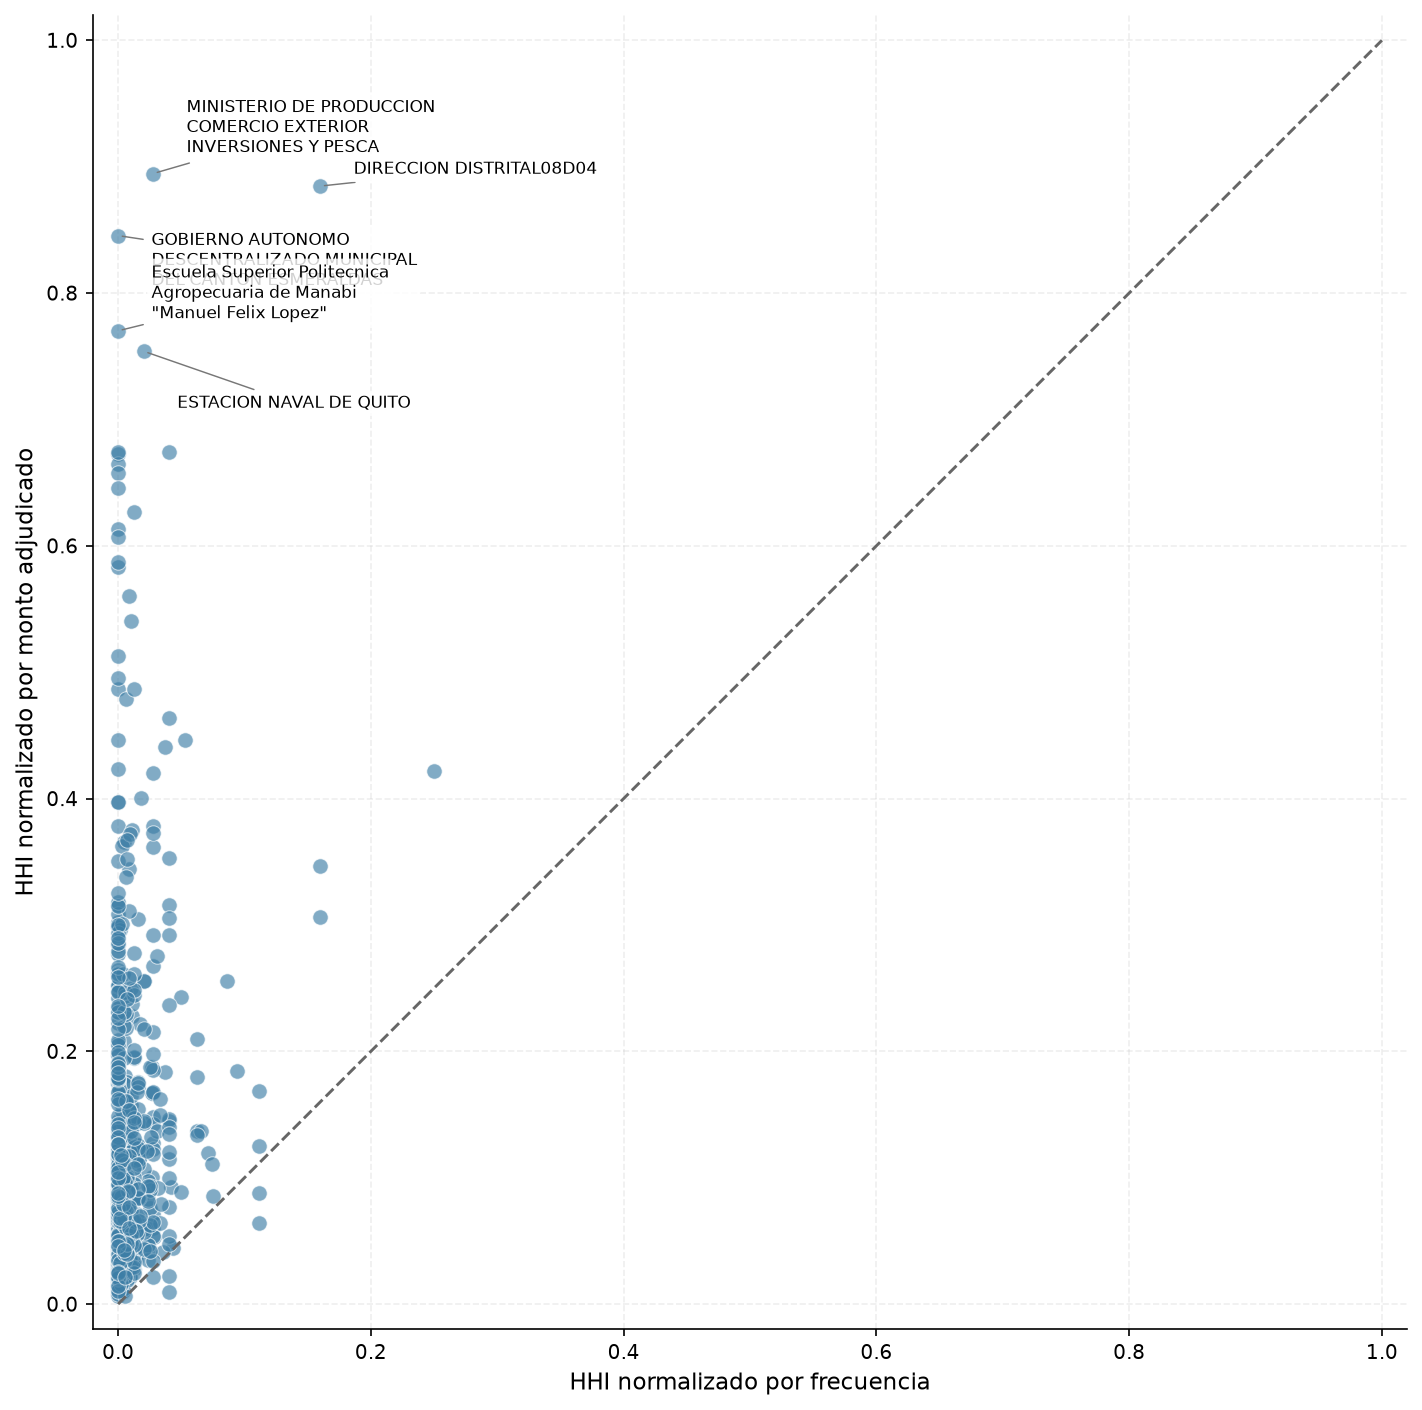

In [10]:
# ============================================================
# PASO 10. FIGURA 6
# CONCENTRACIÓN MONETARIA VS. CONCENTRACIÓN POR FRECUENCIA
# ============================================================
#
# Objetivo:
# Comparar dos dimensiones diferentes de concentración
# para cada entidad contratante:
#
# 1. HHI normalizado por frecuencia:
#    mide qué tan concentrado está el número de adjudicaciones
#    entre los proveedores de una entidad.
#
# 2. HHI normalizado monetario:
#    mide qué tan concentrado está el valor económico adjudicado
#    entre los proveedores de una entidad.
#
# CORRECCIONES METODOLÓGICAS:
#
# - Se excluye Catálogo Electrónico si existieran registros.
# - Se consideran únicamente adjudicaciones de USD 5.000 o más.
# - El criterio de >= 5 adjudicaciones se aplica DESPUÉS
#   del filtro monetario de USD 5.000.
# - Solo se calcula concentración para compradores con
#   al menos 5 adjudicaciones elegibles.
# - El HHI monetario y el HHI por frecuencia se calculan
#   y reportan por separado.
# - Se utiliza HHI normalizado:
#
#       HHI* = (HHI - 1/n) / (1 - 1/n)
#
#   donde n es el número de proveedores distintos.
#
# - Para n = 1, HHI* NO está definido.
# - Se calculan adicionalmente CR4 y entropía normalizada
#   como métricas complementarias.
#
# IMPORTANTE:
# - Un HHI alto NO constituye evidencia de colusión,
#   riesgo o irregularidad.
# - Las métricas deben interpretarse considerando el objeto
#   contractual, la estructura del mercado y sus proveedores.
# ============================================================


import os
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 1. CREAR BASE PARA EL ANÁLISIS DE CONCENTRACIÓN
# ============================================================

base_concentracion = adjudicaciones_df[
    [
        "ocid",
        "buyer_id",
        "supplier_id",
        "award_amount"
    ]
].copy()


# ------------------------------------------------------------
# Convertir monto a numérico
# ------------------------------------------------------------

base_concentracion["award_amount"] = pd.to_numeric(
    base_concentracion["award_amount"],
    errors="coerce"
)


print("=" * 75)
print("CONTROL DEL ANÁLISIS DE CONCENTRACIÓN")
print("=" * 75)

print(
    f"\nRegistros iniciales: "
    f"{len(base_concentracion):,}"
)


# ============================================================
# 2. VALIDAR Y EXCLUIR CATÁLOGO ELECTRÓNICO
# ============================================================
# El universo principal corresponde a Subasta Inversa
# Electrónica; no obstante, se realiza una validación explícita
# para evitar que registros de Catálogo Electrónico generen
# recurrencia o concentración artificial.
# ============================================================

columnas_modalidad_posibles = [
    "tipo_procedimiento",
    "procedure_type",
    "procurement_method_details",
    "tender_procurement_method_details",
    "tender_method_details",
    "modalidad"
]


columna_modalidad = next(
    (
        columna
        for columna in columnas_modalidad_posibles
        if columna in procedimientos_df.columns
    ),
    None
)


if columna_modalidad is not None:

    modalidad_df = (
        procedimientos_df[
            [
                "ocid",
                columna_modalidad
            ]
        ]
        .drop_duplicates(
            subset=["ocid"]
        )
        .copy()
    )


    base_concentracion = (
        base_concentracion
        .merge(
            modalidad_df,
            on="ocid",
            how="left"
        )
    )


    mascara_catalogo = (
        base_concentracion[
            columna_modalidad
        ]
        .astype("string")
        .str.upper()
        .str.contains(
            r"CAT[ÁA]LOGO",
            regex=True,
            na=False
        )
    )


    registros_catalogo = int(
        mascara_catalogo.sum()
    )


    print(
        f"\nRegistros identificados como Catálogo Electrónico: "
        f"{registros_catalogo:,}"
    )


    base_concentracion = (
        base_concentracion[
            ~mascara_catalogo
        ]
        .copy()
    )


else:

    print(
        "\nNo se encontró una columna específica de modalidad "
        "en procedimientos_df."
    )

    print(
        "El universo cargado corresponde a Subasta Inversa "
        "Electrónica 2025; no se aplicó un filtro adicional "
        "de Catálogo Electrónico."
    )


# ============================================================
# 3. FILTRO ANALÍTICO DE USD 5.000
# ============================================================
# Se excluyen adjudicaciones inferiores a USD 5.000 para este
# análisis específico de concentración, conforme a la
# observación metodológica del profesor.
# ============================================================

base_concentracion = base_concentracion[
    base_concentracion["ocid"].notna()
    & base_concentracion["buyer_id"].notna()
    & base_concentracion["supplier_id"].notna()
    & base_concentracion["award_amount"].notna()
    & (base_concentracion["award_amount"] >= 5000)
].copy()


print(
    f"\nRegistros con monto >= USD 5.000: "
    f"{len(base_concentracion):,}"
)


# ============================================================
# 4. ELIMINAR DUPLICADOS EXACTOS
# ============================================================
# Se eliminan únicamente registros exactamente repetidos.
#
# No se elimina automáticamente una segunda adjudicación del
# mismo proveedor dentro del mismo OCID si presenta un monto
# diferente.
# ============================================================

base_concentracion = (
    base_concentracion
    .drop_duplicates(
        subset=[
            "ocid",
            "buyer_id",
            "supplier_id",
            "award_amount"
        ]
    )
    .copy()
)


# ============================================================
# 5. CONSOLIDAR MONTO POR PROCEDIMIENTO Y PROVEEDOR
# ============================================================
# Esto permite:
#
# - contar una sola vez el procedimiento para frecuencia;
# - conservar el monto total asociado al proveedor dentro
#   de ese procedimiento.
# ============================================================

procedimiento_proveedor = (
    base_concentracion
    .groupby(
        [
            "ocid",
            "buyer_id",
            "supplier_id"
        ],
        as_index=False
    )
    .agg(
        monto_procedimiento=(
            "award_amount",
            "sum"
        )
    )
)


print(
    f"Registros procedimiento-proveedor después del filtro: "
    f"{len(procedimiento_proveedor):,}"
)


# ============================================================
# 6. IDENTIFICAR COMPRADORES CON >= 5 ADJUDICACIONES
# ============================================================
# IMPORTANTE:
# Este criterio se calcula DESPUÉS de haber filtrado
# las adjudicaciones con monto >= USD 5.000.
# ============================================================

resumen_entidades = (
    procedimiento_proveedor
    .groupby(
        "buyer_id",
        as_index=False
    )
    .agg(
        numero_adjudicaciones=(
            "ocid",
            "nunique"
        ),

        numero_proveedores=(
            "supplier_id",
            "nunique"
        )
    )
)


entidades_elegibles = (
    resumen_entidades[
        resumen_entidades[
            "numero_adjudicaciones"
        ] >= 5
    ]
    .copy()
)


print(
    f"\nEntidades con al menos 5 adjudicaciones "
    f"de USD 5.000 o más: "
    f"{len(entidades_elegibles):,}"
)


# ============================================================
# 6.1 CONTROL FINAL DE ELEGIBILIDAD PARA CONCENTRACIÓN
# ============================================================
# Este bloque confirma explícitamente:
#
# 1. cuántos compradores existen después del filtro monetario;
# 2. cuántos cumplen el mínimo de cinco adjudicaciones;
# 3. que ninguna entidad con menos de cinco adjudicaciones
#    haya sido incorporada al análisis.
# ============================================================

print("\n" + "=" * 75)
print("VALIDACIÓN DE CRITERIOS DE CONCENTRACIÓN")
print("=" * 75)

print(
    f"Registros procedimiento-proveedor con monto >= USD 5.000: "
    f"{len(procedimiento_proveedor):,}"
)

print(
    f"Compradores después del filtro de USD 5.000: "
    f"{resumen_entidades['buyer_id'].nunique():,}"
)

print(
    f"Compradores elegibles con >= 5 adjudicaciones: "
    f"{len(entidades_elegibles):,}"
)

print(
    f"Mínimo de adjudicaciones entre compradores elegibles: "
    f"{entidades_elegibles['numero_adjudicaciones'].min():,}"
)

print(
    f"Máximo de adjudicaciones entre compradores elegibles: "
    f"{entidades_elegibles['numero_adjudicaciones'].max():,}"
)

# Calcular aparte para evitar problemas de sintaxis
compradores_menos_5 = (
    entidades_elegibles["numero_adjudicaciones"] < 5
).sum()

print(
    "Compradores elegibles con menos de 5 adjudicaciones:",
    compradores_menos_5
)


# ------------------------------------------------------------
# Mantener únicamente compradores elegibles
# ------------------------------------------------------------

procedimiento_proveedor = (
    procedimiento_proveedor[
        procedimiento_proveedor[
            "buyer_id"
        ].isin(
            entidades_elegibles[
                "buyer_id"
            ]
        )
    ]
    .copy()
)


print(
    f"Registros procedimiento-proveedor correspondientes "
    f"a compradores elegibles: "
    f"{len(procedimiento_proveedor):,}"
)


# ============================================================
# 7. CONSOLIDAR RELACIÓN COMPRADOR-PROVEEDOR
# ============================================================

relacion_concentracion = (
    procedimiento_proveedor
    .groupby(
        [
            "buyer_id",
            "supplier_id"
        ],
        as_index=False
    )
    .agg(
        frecuencia=(
            "ocid",
            "nunique"
        ),

        monto_total=(
            "monto_procedimiento",
            "sum"
        )
    )
)


# ============================================================
# 8. CALCULAR TOTALES POR ENTIDAD
# ============================================================

totales_entidad = (
    relacion_concentracion
    .groupby(
        "buyer_id",
        as_index=False
    )
    .agg(
        total_adjudicaciones=(
            "frecuencia",
            "sum"
        ),

        total_monto=(
            "monto_total",
            "sum"
        ),

        numero_proveedores=(
            "supplier_id",
            "nunique"
        )
    )
)


relacion_concentracion = (
    relacion_concentracion
    .merge(
        totales_entidad,
        on="buyer_id",
        how="left"
    )
)


# ============================================================
# 9. PARTICIPACIONES POR FRECUENCIA Y MONTO
# ============================================================

relacion_concentracion[
    "participacion_frecuencia"
] = (
    relacion_concentracion[
        "frecuencia"
    ]
    /
    relacion_concentracion[
        "total_adjudicaciones"
    ]
)


relacion_concentracion[
    "participacion_monetaria"
] = (
    relacion_concentracion[
        "monto_total"
    ]
    /
    relacion_concentracion[
        "total_monto"
    ]
)


# ============================================================
# 10. COMPONENTES DEL HHI
# ============================================================

relacion_concentracion[
    "hhi_comp_frecuencia"
] = (
    relacion_concentracion[
        "participacion_frecuencia"
    ] ** 2
)


relacion_concentracion[
    "hhi_comp_monetario"
] = (
    relacion_concentracion[
        "participacion_monetaria"
    ] ** 2
)


# ============================================================
# 11. CALCULAR HHI SIN NORMALIZAR POR ENTIDAD
# ============================================================

hhi_entidad = (
    relacion_concentracion
    .groupby(
        "buyer_id",
        as_index=False
    )
    .agg(
        hhi_frecuencia=(
            "hhi_comp_frecuencia",
            "sum"
        ),

        hhi_monetario=(
            "hhi_comp_monetario",
            "sum"
        ),

        numero_proveedores=(
            "supplier_id",
            "nunique"
        ),

        numero_adjudicaciones=(
            "frecuencia",
            "sum"
        ),

        monto_total_adjudicado=(
            "monto_total",
            "sum"
        )
    )
)


# ============================================================
# 12. NORMALIZAR HHI
# ============================================================
#
# HHI* = (HHI - 1/n) / (1 - 1/n)
#
# n = número de proveedores distintos.
#
# Si n = 1:
# HHI* NO está definido.
# ============================================================

def normalizar_hhi(
    hhi,
    n
):

    if n <= 1:
        return np.nan


    hhi_normalizado = (
        (
            hhi
            - (1 / n)
        )
        /
        (
            1
            - (1 / n)
        )
    )


    # Control por precisión numérica.
    return float(
        np.clip(
            hhi_normalizado,
            0,
            1
        )
    )


hhi_entidad[
    "hhi_frecuencia_normalizado"
] = (
    hhi_entidad.apply(
        lambda fila:
        normalizar_hhi(
            fila[
                "hhi_frecuencia"
            ],
            fila[
                "numero_proveedores"
            ]
        ),
        axis=1
    )
)


hhi_entidad[
    "hhi_monetario_normalizado"
] = (
    hhi_entidad.apply(
        lambda fila:
        normalizar_hhi(
            fila[
                "hhi_monetario"
            ],
            fila[
                "numero_proveedores"
            ]
        ),
        axis=1
    )
)


# ============================================================
# 13. CALCULAR CR4
# ============================================================
# CR4:
# participación acumulada de los cuatro proveedores principales.
#
# Se calcula por separado para:
#
# - frecuencia
# - monto
# ============================================================

def calcular_cr4(grupo):

    cr4_frecuencia = (
        grupo[
            "participacion_frecuencia"
        ]
        .nlargest(4)
        .sum()
    )


    cr4_monetario = (
        grupo[
            "participacion_monetaria"
        ]
        .nlargest(4)
        .sum()
    )


    return pd.Series(
        {
            "cr4_frecuencia":
                cr4_frecuencia,

            "cr4_monetario":
                cr4_monetario
        }
    )


cr4_entidad = (
    relacion_concentracion
    .groupby(
        "buyer_id"
    )
    .apply(
        calcular_cr4,
        include_groups=False
    )
    .reset_index()
)


# ============================================================
# 14. CALCULAR ENTROPÍA NORMALIZADA
# ============================================================
# Entropía normalizada:
#
# H = -SUM(p * ln(p)) / ln(n)
#
# Valores cercanos a 1:
# mayor diversidad en la distribución.
#
# Valores cercanos a 0:
# menor diversidad.
#
# Para n = 1 no está definida.
# ============================================================

def entropia_normalizada(
    participaciones
):

    participaciones = (
        np.asarray(
            participaciones,
            dtype=float
        )
    )


    participaciones = (
        participaciones[
            participaciones > 0
        ]
    )


    n = len(
        participaciones
    )


    if n <= 1:
        return np.nan


    entropia = (
        -np.sum(
            participaciones
            * np.log(
                participaciones
            )
        )
    )


    return float(
        entropia
        / np.log(n)
    )


entropia_entidad = (
    relacion_concentracion
    .groupby(
        "buyer_id"
    )
    .apply(
        lambda grupo:
        pd.Series(
            {
                "entropia_frecuencia":
                    entropia_normalizada(
                        grupo[
                            "participacion_frecuencia"
                        ]
                    ),

                "entropia_monetaria":
                    entropia_normalizada(
                        grupo[
                            "participacion_monetaria"
                        ]
                    )
            }
        ),
        include_groups=False
    )
    .reset_index()
)


# ============================================================
# 15. INCORPORAR CR4 Y ENTROPÍA
# ============================================================

hhi_entidad = (
    hhi_entidad
    .merge(
        cr4_entidad,
        on="buyer_id",
        how="left"
    )
    .merge(
        entropia_entidad,
        on="buyer_id",
        how="left"
    )
)


# ============================================================
# 16. INCORPORAR NOMBRE DE LA ENTIDAD
# ============================================================

def nombre_representativo_concentracion(
    serie
):

    serie = (
        serie
        .dropna()
    )


    if len(serie) == 0:
        return None


    moda = (
        serie.mode()
    )


    if len(moda) > 0:
        return moda.iloc[0]


    return serie.iloc[0]


nombres_entidades = (
    procedimientos_df
    .groupby(
        "buyer_id",
        as_index=False
    )
    .agg(
        buyer_name=(
            "buyer_name",
            nombre_representativo_concentracion
        )
    )
)


hhi_entidad = (
    hhi_entidad
    .merge(
        nombres_entidades,
        on="buyer_id",
        how="left"
    )
)


# ============================================================
# 17. IDENTIFICAR CASOS CON UN SOLO PROVEEDOR
# ============================================================

casos_un_proveedor = (
    hhi_entidad[
        hhi_entidad[
            "numero_proveedores"
        ] == 1
    ]
    .copy()
)


print(
    f"\nEntidades elegibles con un solo proveedor "
    f"(HHI* no definido): "
    f"{len(casos_un_proveedor):,}"
)


# ============================================================
# 18. CREAR BASE FINAL PARA FIGURA 6
# ============================================================

hhi_figura = (
    hhi_entidad
    .dropna(
        subset=[
            "hhi_frecuencia_normalizado",
            "hhi_monetario_normalizado"
        ]
    )
    .copy()
)


print(
    f"Entidades representadas en la Figura 6: "
    f"{len(hhi_figura):,}"
)


# ============================================================
# 19. RESUMEN DE HHI NORMALIZADO
# ============================================================

mediana_hhi_frecuencia = (
    hhi_figura[
        "hhi_frecuencia_normalizado"
    ]
    .median()
)


mediana_hhi_monetario = (
    hhi_figura[
        "hhi_monetario_normalizado"
    ]
    .median()
)


print(
    f"\nMediana HHI* por frecuencia: "
    f"{mediana_hhi_frecuencia:.3f}"
)

print(
    f"Mediana HHI* monetario: "
    f"{mediana_hhi_monetario:.3f}"
)


# ============================================================
# 20. DIFERENCIA ENTRE AMBOS HHI
# ============================================================
# Diferencia positiva:
#
# HHI monetario > HHI frecuencia.
#
# Diferencia negativa:
#
# HHI frecuencia > HHI monetario.
#
# La diferencia NO se interpreta automáticamente como riesgo.
# ============================================================

hhi_figura[
    "diferencia_hhi"
] = (
    hhi_figura[
        "hhi_monetario_normalizado"
    ]
    -
    hhi_figura[
        "hhi_frecuencia_normalizado"
    ]
)


hhi_figura[
    "diferencia_absoluta"
] = (
    hhi_figura[
        "diferencia_hhi"
    ]
    .abs()
)


# ============================================================
# 21. TOP 10 ENTIDADES CON MAYOR DIFERENCIA
# ============================================================

top_diferencias_tabla = (
    hhi_figura
    .sort_values(
        "diferencia_absoluta",
        ascending=False
    )
    .head(10)
    .copy()
)


tabla_figura_6 = (
    top_diferencias_tabla[
        [
            "buyer_name",
            "numero_adjudicaciones",
            "numero_proveedores",
            "hhi_frecuencia_normalizado",
            "hhi_monetario_normalizado",
            "diferencia_hhi",
            "cr4_frecuencia",
            "cr4_monetario",
            "entropia_frecuencia",
            "entropia_monetaria"
        ]
    ]
    .rename(
        columns={
            "buyer_name":
                "Entidad contratante",

            "numero_adjudicaciones":
                "Adjudicaciones",

            "numero_proveedores":
                "Proveedores",

            "hhi_frecuencia_normalizado":
                "HHI* frecuencia",

            "hhi_monetario_normalizado":
                "HHI* monetario",

            "diferencia_hhi":
                "Diferencia HHI*",

            "cr4_frecuencia":
                "CR4 frecuencia",

            "cr4_monetario":
                "CR4 monetario",

            "entropia_frecuencia":
                "Entropía frecuencia",

            "entropia_monetaria":
                "Entropía monetaria"
        }
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Redondear únicamente para presentación
# ------------------------------------------------------------

columnas_decimales = [
    "HHI* frecuencia",
    "HHI* monetario",
    "Diferencia HHI*",
    "CR4 frecuencia",
    "CR4 monetario",
    "Entropía frecuencia",
    "Entropía monetaria"
]


tabla_figura_6[
    columnas_decimales
] = (
    tabla_figura_6[
        columnas_decimales
    ]
    .round(3)
)


print(
    "\nENTIDADES CON MAYOR DIFERENCIA ENTRE "
    "CONCENTRACIÓN MONETARIA Y POR FRECUENCIA\n"
)


display(
    tabla_figura_6
)


# ============================================================
# 22. CREAR FIGURA 6
# ============================================================
# Cada punto representa una entidad contratante.
#
# Ambos ejes utilizan la misma escala 0-1 para permitir
# una comparación directa entre ambas dimensiones.
# ============================================================

fig, ax = plt.subplots(
    figsize=(10.5, 9.5),
    dpi=150
)


ax.scatter(
    hhi_figura[
        "hhi_frecuencia_normalizado"
    ],
    hhi_figura[
        "hhi_monetario_normalizado"
    ],
    s=55,
    alpha=0.65,
    color="#3D7EA6",
    edgecolor="white",
    linewidth=0.5
)


# ============================================================
# 23. LÍNEA DE IGUALDAD
# ============================================================
# Sobre la línea:
# concentración monetaria = concentración por frecuencia.
#
# Encima:
# concentración monetaria > frecuencia.
#
# Debajo:
# concentración por frecuencia > monetaria.
# ============================================================

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.4,
    color="#666666"
)


# ============================================================
# 24. ETIQUETAR LAS 5 MAYORES DIFERENCIAS
# ============================================================

top_5_diferencias = (
    hhi_figura
    .sort_values(
        "diferencia_absoluta",
        ascending=False
    )
    .head(5)
    .copy()
)


def dividir_nombre_figura_6(
    texto,
    ancho=28
):

    if pd.isna(texto):
        return "No informado"


    return "\n".join(
        textwrap.wrap(
            str(texto),
            width=ancho,
            break_long_words=False,
            break_on_hyphens=False
        )
    )


desplazamientos = [
    (16, 22),
    (16, -12),
    (16, 18),
    (16, -25),
    (16, 8)
]


for (
    (_, fila),
    desplazamiento
) in zip(
    top_5_diferencias.iterrows(),
    desplazamientos
):

    nombre = (
        dividir_nombre_figura_6(
            fila[
                "buyer_name"
            ]
        )
    )


    ax.annotate(
        nombre,

        (
            fila[
                "hhi_frecuencia_normalizado"
            ],

            fila[
                "hhi_monetario_normalizado"
            ]
        ),

        xytext=desplazamiento,

        textcoords="offset points",

        fontsize=8,

        ha="left",
        va="center",

        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=0.82
        ),

        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.7,
            color="#777777"
        )
    )


# ============================================================
# 25. FORMATO DE LOS EJES
# ============================================================

ax.set_xlabel(
    "HHI normalizado por frecuencia",
    fontsize=11
)


ax.set_ylabel(
    "HHI normalizado por monto adjudicado",
    fontsize=11
)


ax.set_xlim(
    -0.02,
    1.02
)

ax.set_ylim(
    -0.02,
    1.02
)


ax.set_aspect(
    "equal",
    adjustable="box"
)


# ============================================================
# 26. ESTILO VISUAL
# ============================================================

ax.grid(
    True,
    linestyle="--",
    alpha=0.20
)

ax.set_axisbelow(True)


ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)


ax.tick_params(
    axis="both",
    labelsize=9.5
)


plt.tight_layout()


# ============================================================
# 27. GUARDAR FIGURA 6
# ============================================================

ruta_figura_6 = os.path.join(
    ruta_figuras,
    "figura_6_hhi_normalizado_monetario_frecuencia_2025.png"
)


fig.savefig(
    ruta_figura_6,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


print(
    "\nFigura 6 guardada en:"
)

print(
    ruta_figura_6
)


plt.show()

CONTROL DE FIGURA 7 - CONCENTRACIÓN MONETARIA

Entidades disponibles para el análisis: 687
Adjudicaciones mínimas entre las entidades analizadas: 5
Número mínimo de proveedores: 3

10 ENTIDADES CON MAYOR CONCENTRACIÓN MONETARIA



,Ranking,Entidad contratante,Adjudicaciones,Proveedores,HHI* monetario,CR4 monetario,Entropía monetaria
0,1,MINISTERIO DE PRODUCCION COMERCIO EXTERIOR INV...,6,5,0.895,0.994,0.146
1,2,DIRECCION DISTRITAL08D04,5,3,0.885,1.000,0.174
2,3,GOBIERNO AUTONOMO DESCENTRALIZADO MUNICIPAL DE...,12,12,0.845,0.973,0.167
3,4,Escuela Superior Politecnica Agropecuaria de M...,12,12,0.770,0.944,0.242
4,5,ESTACION NAVAL DE QUITO,7,6,0.754,0.976,0.284
5,6,DIRECCION DISTRITAL 08D01 - ESMERALDAS - EDUCA...,5,4,0.675,1.000,0.366
6,7,EMPRESA PUBLICA METROPOLITANA MERCADO MAYORIST...,5,5,0.674,0.981,0.373
7,8,HOSPITAL GENERAL MONTE SINAI,5,5,0.673,0.994,0.342
8,9,GOBIERNO AUTONOMO DESCENTRALIZADO MUNICIPAL IN...,5,5,0.665,0.991,0.364
9,10,Municipio El Chaco,7,7,0.658,0.949,0.370



HHI* monetario máximo del Top 10: 0.895
HHI* monetario mínimo del Top 10: 0.658
CR4 monetario máximo del Top 10: 1.000
Entropía monetaria mínima del Top 10: 0.146

Figura 7 guardada en:
../reports/figures/figura_7_entidades_mayor_concentracion_monetaria_2025.png


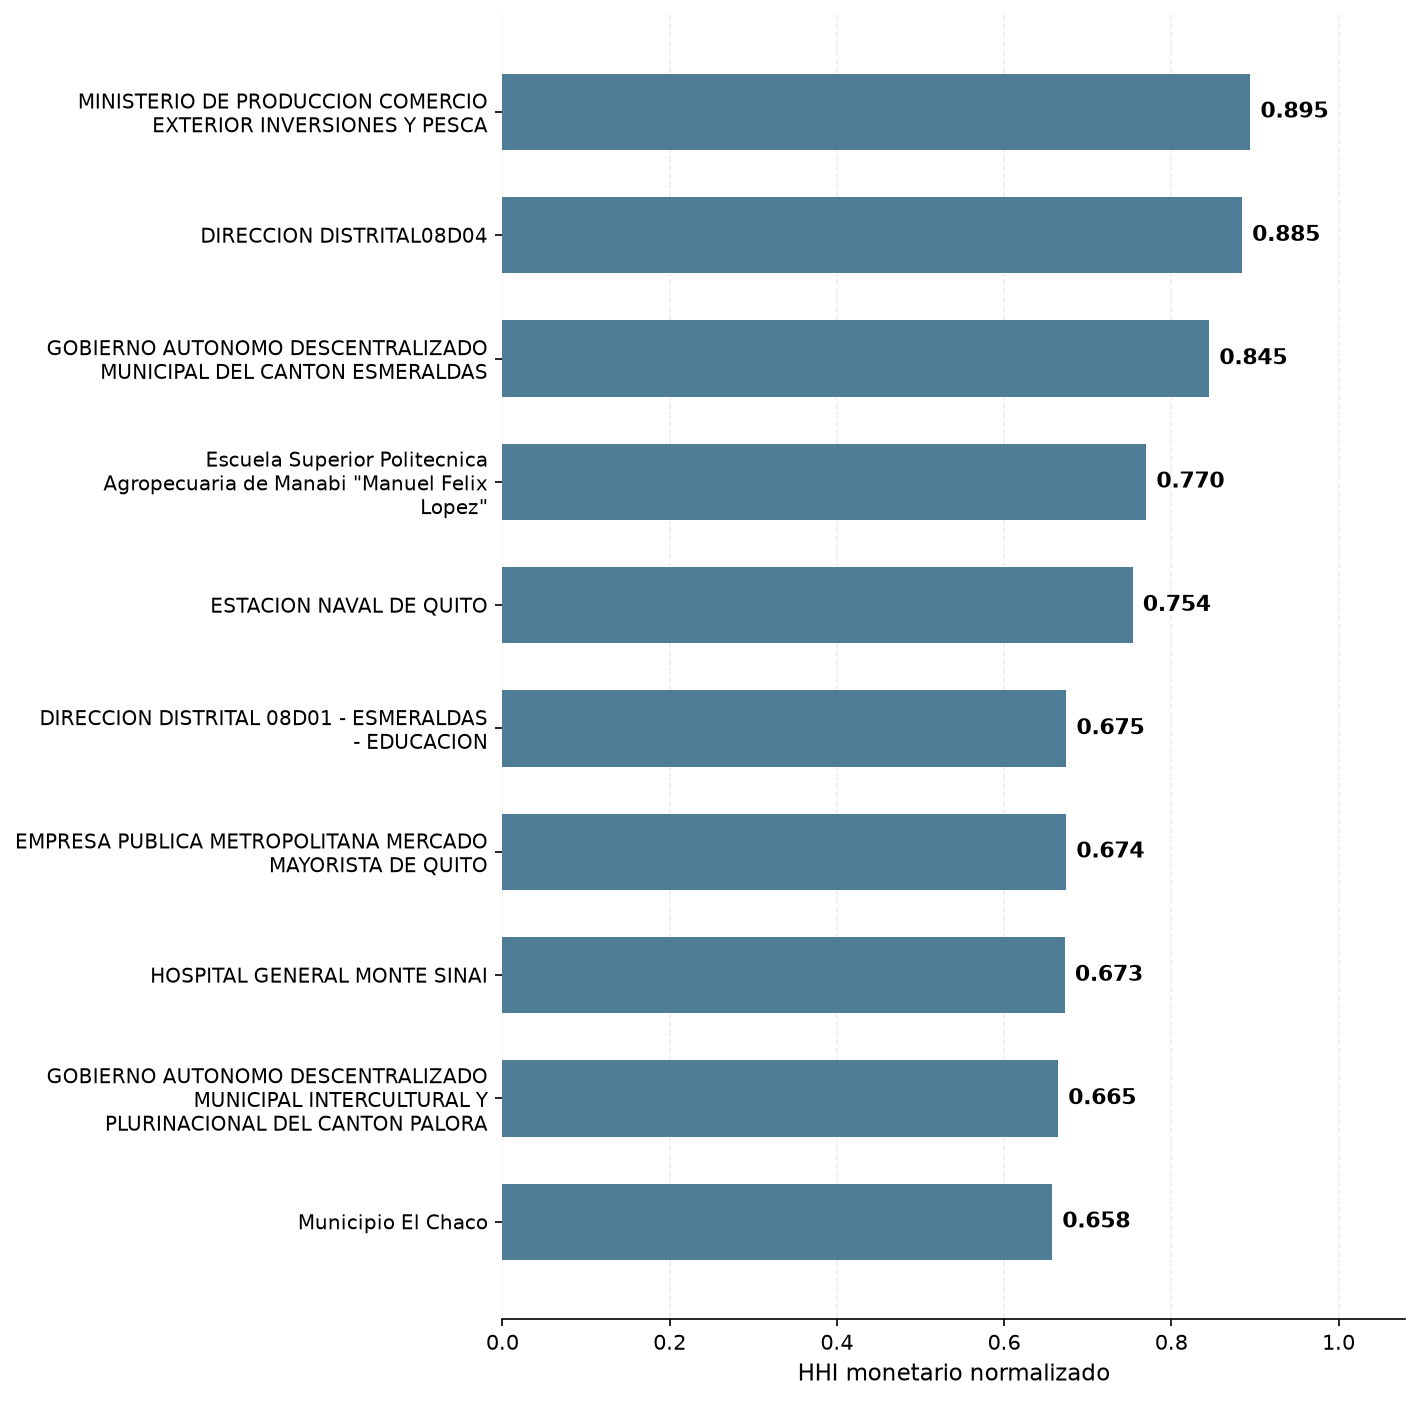

In [13]:
# ============================================================
# PASO 11. FIGURA 7
# ENTIDADES CON MAYOR CONCENTRACIÓN MONETARIA
# ============================================================
#
# Objetivo:
# Identificar las entidades contratantes con mayores niveles
# de concentración del valor económico adjudicado entre sus
# proveedores.
#
# BASE METODOLÓGICA:
# Esta figura utiliza directamente los resultados del análisis
# de concentración desarrollado en la Figura 6.
#
# Por tanto, ya se encuentran aplicados los siguientes criterios:
#
# - Adjudicaciones con monto >= USD 5.000.
# - Exclusión de Catálogo Electrónico cuando la modalidad
#   puede ser identificada.
# - Entidades con al menos 5 adjudicaciones.
# - HHI monetario y HHI por frecuencia calculados por separado.
# - HHI normalizado:
#
#       HHI* = (HHI - 1/n) / (1 - 1/n)
#
#   donde n = número de proveedores.
#
# - Para n = 1, HHI* no está definido.
#
# Indicadores complementarios:
#
# - CR4 monetario:
#   proporción del monto adjudicado concentrado en los cuatro
#   proveedores con mayor participación económica.
#
# - Entropía monetaria normalizada:
#   valores cercanos a 1 indican mayor diversidad;
#   valores cercanos a 0 indican menor diversidad.
#
# IMPORTANTE:
# Una concentración monetaria elevada NO constituye por sí sola
# evidencia de colusión, riesgo o irregularidad.
# Su interpretación requiere considerar el objeto contractual,
# los proveedores participantes y el mercado relevante.
# ============================================================


import os
import textwrap
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 1. VALIDAR QUE EXISTA LA BASE DE CONCENTRACIÓN
# ============================================================
# hhi_figura fue construida y validada en la Figura 6.
# No se recalculan los indicadores para evitar inconsistencias.
# ============================================================

columnas_requeridas_figura_7 = [
    "buyer_id",
    "buyer_name",
    "numero_adjudicaciones",
    "numero_proveedores",
    "hhi_monetario_normalizado",
    "cr4_monetario",
    "entropia_monetaria"
]


columnas_faltantes_figura_7 = [
    columna
    for columna in columnas_requeridas_figura_7
    if columna not in hhi_figura.columns
]


if columnas_faltantes_figura_7:

    raise ValueError(
        "Faltan columnas necesarias para la Figura 7: "
        + ", ".join(columnas_faltantes_figura_7)
        + ". Ejecutar primero el PASO 10 - FIGURA 6."
    )


# ============================================================
# 2. CREAR BASE ESPECÍFICA PARA FIGURA 7
# ============================================================

base_figura_7 = hhi_figura[
    columnas_requeridas_figura_7
].copy()


# ------------------------------------------------------------
# Validar HHI monetario definido
# ------------------------------------------------------------

base_figura_7 = (
    base_figura_7
    .dropna(
        subset=[
            "hhi_monetario_normalizado"
        ]
    )
    .copy()
)


print("=" * 75)
print("CONTROL DE FIGURA 7 - CONCENTRACIÓN MONETARIA")
print("=" * 75)

print(
    f"\nEntidades disponibles para el análisis: "
    f"{len(base_figura_7):,}"
)

print(
    f"Adjudicaciones mínimas entre las entidades analizadas: "
    f"{base_figura_7['numero_adjudicaciones'].min():,.0f}"
)

print(
    f"Número mínimo de proveedores: "
    f"{base_figura_7['numero_proveedores'].min():,.0f}"
)


# ============================================================
# 3. SELECCIONAR TOP 10 POR HHI MONETARIO NORMALIZADO
# ============================================================
# El ranking utiliza como criterio principal el
# HHI monetario normalizado.
#
# En caso de igualdad en el HHI*, el CR4 monetario se utiliza
# únicamente como criterio secundario de ordenamiento.
#
# CR4 y entropía se mantienen como indicadores complementarios
# y NO se combinan ni promedian con el HHI.
# ============================================================

top_concentracion_monetaria = (
    base_figura_7
    .sort_values(
        [
            "hhi_monetario_normalizado",
            "cr4_monetario"
        ],
        ascending=[
            False,
            False
        ]
    )
    .head(10)
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 4. CREAR RANKING
# ============================================================

top_concentracion_monetaria[
    "ranking"
] = (
    range(
        1,
        len(top_concentracion_monetaria) + 1
    )
)


# ============================================================
# 5. TABLA DE RESULTADOS
# ============================================================

tabla_figura_7 = (
    top_concentracion_monetaria[
        [
            "ranking",
            "buyer_name",
            "numero_adjudicaciones",
            "numero_proveedores",
            "hhi_monetario_normalizado",
            "cr4_monetario",
            "entropia_monetaria"
        ]
    ]
    .rename(
        columns={
            "ranking":
                "Ranking",

            "buyer_name":
                "Entidad contratante",

            "numero_adjudicaciones":
                "Adjudicaciones",

            "numero_proveedores":
                "Proveedores",

            "hhi_monetario_normalizado":
                "HHI* monetario",

            "cr4_monetario":
                "CR4 monetario",

            "entropia_monetaria":
                "Entropía monetaria"
        }
    )
    .copy()
)


# ------------------------------------------------------------
# Redondear únicamente para presentación
# ------------------------------------------------------------

tabla_figura_7[
    [
        "HHI* monetario",
        "CR4 monetario",
        "Entropía monetaria"
    ]
] = (
    tabla_figura_7[
        [
            "HHI* monetario",
            "CR4 monetario",
            "Entropía monetaria"
        ]
    ]
    .round(3)
)


print(
    "\n10 ENTIDADES CON MAYOR CONCENTRACIÓN MONETARIA\n"
)


# DataFrame normal para compatibilidad con PyCharm/Jupyter.
display(
    tabla_figura_7
)


# ============================================================
# 6. CONTROLES DESCRIPTIVOS DEL TOP 10
# ============================================================

print(
    f"\nHHI* monetario máximo del Top 10: "
    f"{top_concentracion_monetaria['hhi_monetario_normalizado'].max():.3f}"
)

print(
    f"HHI* monetario mínimo del Top 10: "
    f"{top_concentracion_monetaria['hhi_monetario_normalizado'].min():.3f}"
)

print(
    f"CR4 monetario máximo del Top 10: "
    f"{top_concentracion_monetaria['cr4_monetario'].max():.3f}"
)

print(
    f"Entropía monetaria mínima del Top 10: "
    f"{top_concentracion_monetaria['entropia_monetaria'].min():.3f}"
)


# ============================================================
# 7. PREPARAR NOMBRES COMPLETOS PARA LA FIGURA
# ============================================================

def dividir_nombre_figura_7(
    texto,
    ancho=38
):

    if pd.isna(texto):
        return "No informado"

    return "\n".join(
        textwrap.wrap(
            str(texto),
            width=ancho,
            break_long_words=False,
            break_on_hyphens=False
        )
    )


top_concentracion_monetaria[
    "nombre_figura"
] = (
    top_concentracion_monetaria[
        "buyer_name"
    ]
    .apply(
        lambda texto:
        dividir_nombre_figura_7(
            texto,
            ancho=38
        )
    )
)


# ============================================================
# 8. ORDENAR PARA GRÁFICO HORIZONTAL
# ============================================================

top_concentracion_grafico = (
    top_concentracion_monetaria
    .sort_values(
        "hhi_monetario_normalizado",
        ascending=True
    )
    .copy()
)


# ============================================================
# 9. CREAR FIGURA 7
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 10),
    dpi=150
)


barras = ax.barh(
    top_concentracion_grafico[
        "nombre_figura"
    ],

    top_concentracion_grafico[
        "hhi_monetario_normalizado"
    ],

    color="#4F7D95",
    height=0.62
)


# ============================================================
# 10. MOSTRAR HHI* AL FINAL DE CADA BARRA
# ============================================================

for barra, valor in zip(

    barras,

    top_concentracion_grafico[
        "hhi_monetario_normalizado"
    ]
):

    ax.text(
        valor + 0.012,

        barra.get_y()
        + barra.get_height() / 2,

        f"{valor:.3f}",

        va="center",
        ha="left",

        fontsize=10.5,
        fontweight="bold"
    )


# ============================================================
# 11. FORMATO DEL EJE X
# ============================================================

ax.set_xlabel(
    "HHI monetario normalizado",
    fontsize=11
)

ax.set_ylabel("")


ax.set_xlim(
    0,
    1.08
)


# ------------------------------------------------------------
# Mostrar escala completa 0-1
# ------------------------------------------------------------

ax.set_xticks(
    [
        0.0,
        0.2,
        0.4,
        0.6,
        0.8,
        1.0
    ]
)


# ============================================================
# 12. ESTILO VISUAL
# ============================================================

ax.xaxis.grid(
    True,
    linestyle="--",
    alpha=0.20
)

ax.set_axisbelow(True)


ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)

ax.spines[
    "left"
].set_visible(False)


ax.tick_params(
    axis="y",
    labelsize=9.5
)

ax.tick_params(
    axis="x",
    labelsize=10
)


# ============================================================
# 13. AJUSTAR ESPACIO PARA NOMBRES COMPLETOS
# ============================================================

plt.subplots_adjust(
    left=0.52,
    right=0.95,
    top=0.97,
    bottom=0.10
)


# ============================================================
# 14. GUARDAR FIGURA 7
# ============================================================

ruta_figura_7 = os.path.join(
    ruta_figuras,
    "figura_7_entidades_mayor_concentracion_monetaria_2025.png"
)


fig.savefig(
    ruta_figura_7,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


print(
    "\nFigura 7 guardada en:"
)

print(
    ruta_figura_7
)


plt.show()

CONTROL DE FIGURA 8 - CONCENTRACIÓN POR FRECUENCIA

Entidades disponibles para el análisis: 687
Adjudicaciones mínimas entre las entidades analizadas: 5
Número mínimo de proveedores: 3

10 ENTIDADES CON MAYOR CONCENTRACIÓN POR FRECUENCIA



,Ranking,Entidad contratante,Adjudicaciones,Proveedores,HHI* frecuencia,CR4 frecuencia,Entropía frecuencia
0,1,EMPRESA PUBLICA MUNICIPAL DE AGUA POTABLE ALCA...,8,4,0.250,1.000,0.774
1,2,GOBIERNO AUTONOMO DESCENTRALIZADO PARROQUIAL V...,5,3,0.160,1.000,0.865
2,3,DIRECCION DISTRITAL08D04,5,3,0.160,1.000,0.865
3,4,GAD. PQ. RURAL SANSAHUARI,5,3,0.160,1.000,0.865
4,5,HOSPITAL BASICO ALAUSI,6,4,0.111,1.000,0.896
5,6,CENTRO PARA GRUPOS DE ATENCION PRIORITARIA CEGAP,9,6,0.111,0.778,0.882
6,7,"EMPRESA PUBLICA MUNICIPAL DE AGUA POTABLE, ALC...",6,4,0.111,1.000,0.896
7,8,UNIDAD DE ACCION SOCIAL DEL GOBIERNO AUTONOMO ...,6,4,0.111,1.000,0.896
8,9,HOSPITAL SAN VICENTE DE PAUL,13,8,0.094,0.692,0.885
9,10,"EMPRESA PUBLICA MUNICIPAL DE AGUA POTABLE, ALC...",25,10,0.086,0.760,0.854



HHI* frecuencia máximo del Top 10: 0.250
HHI* frecuencia mínimo del Top 10: 0.086
CR4 frecuencia máximo del Top 10: 1.000
Entropía frecuencia mínima del Top 10: 0.774

Figura 8 guardada en:
../reports/figures/figura_8_entidades_mayor_concentracion_frecuencia_2025.png


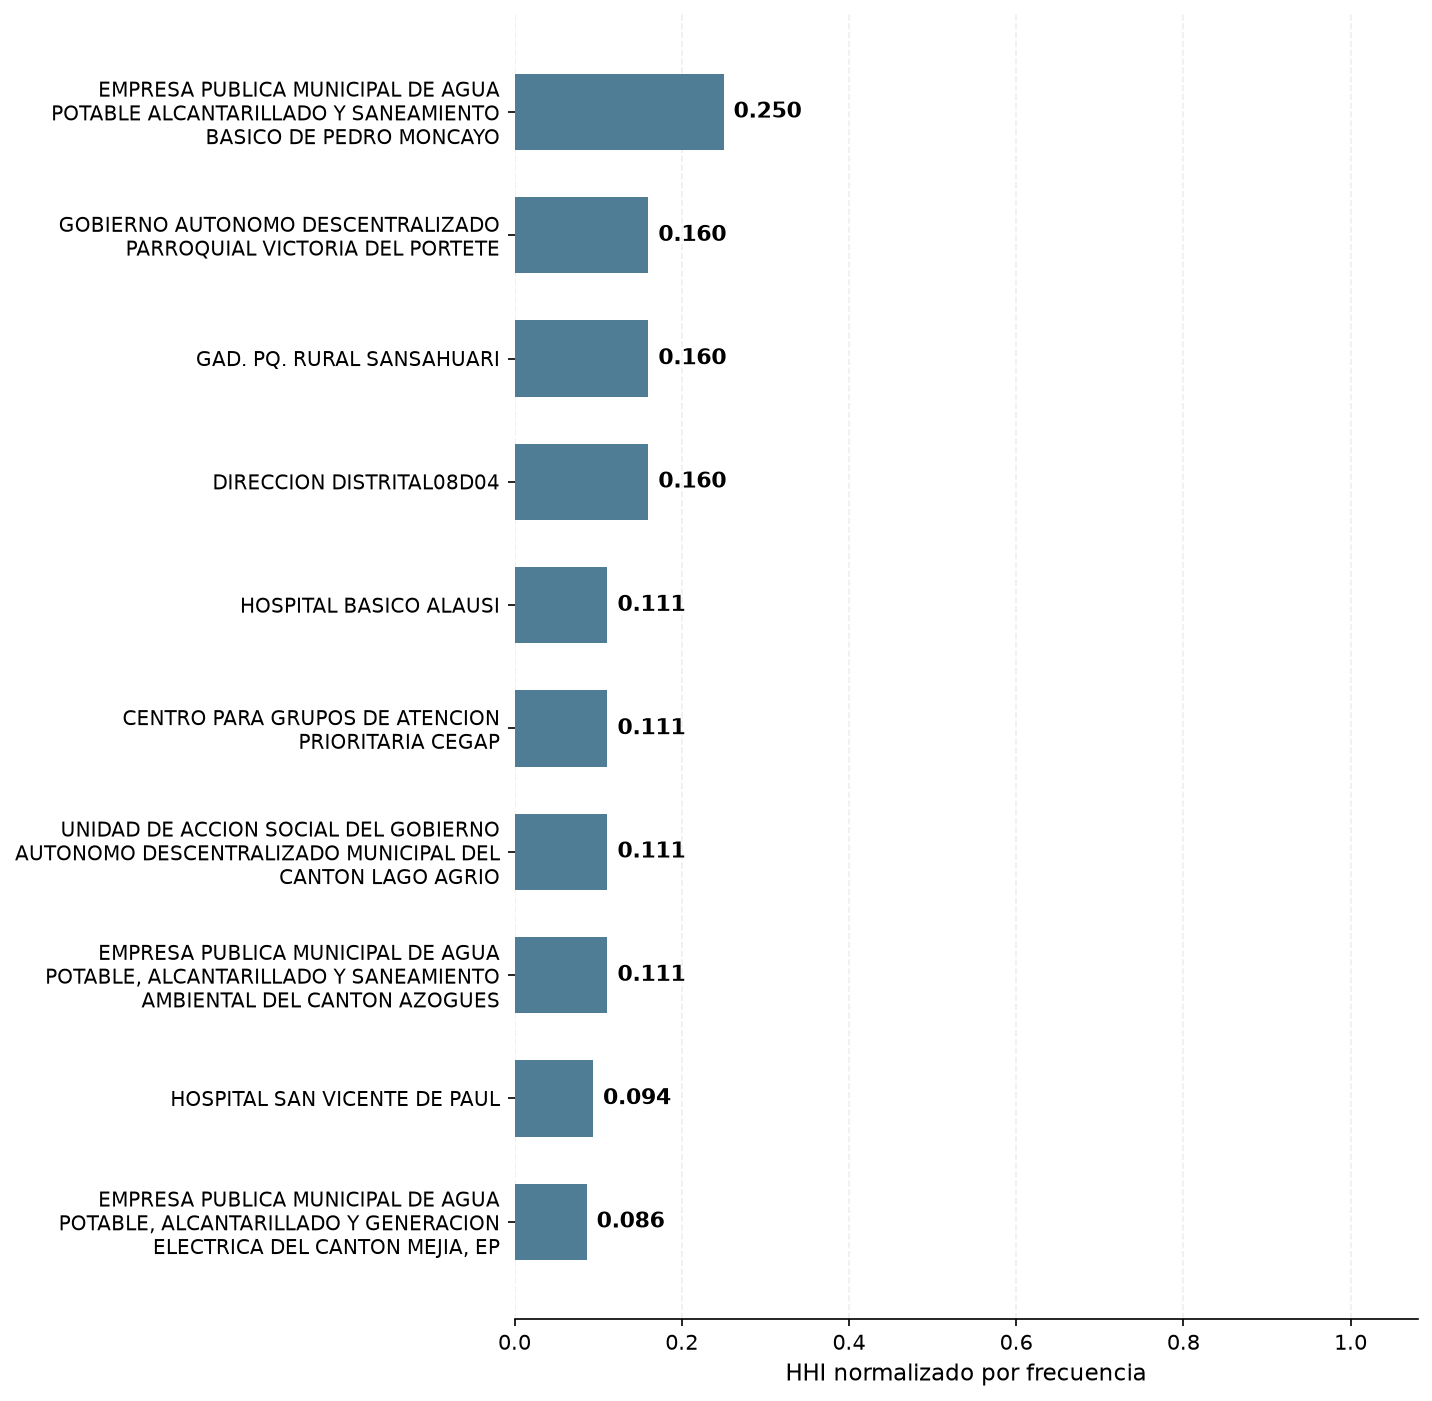

In [14]:
# ============================================================
# PASO 12. FIGURA 8
# ENTIDADES CON MAYOR CONCENTRACIÓN POR FRECUENCIA
# ============================================================
#
# Objetivo:
# Identificar las entidades contratantes donde el número de
# adjudicaciones presenta una mayor concentración entre sus
# proveedores.
#
# BASE METODOLÓGICA:
# Esta figura utiliza directamente los resultados del análisis
# de concentración desarrollado y validado en la Figura 6.
#
# Por tanto, ya se encuentran aplicados:
#
# - Adjudicaciones con monto >= USD 5.000.
# - Exclusión de Catálogo Electrónico cuando fue posible
#   identificar la modalidad.
# - Entidades con al menos 5 adjudicaciones.
# - HHI monetario y HHI por frecuencia calculados por separado.
# - HHI normalizado:
#
#       HHI* = (HHI - 1/n) / (1 - 1/n)
#
#   donde n = número de proveedores.
#
# - Para n = 1, HHI* no está definido.
#
# Indicadores complementarios:
#
# - CR4 por frecuencia:
#   proporción de las adjudicaciones acumuladas por los cuatro
#   proveedores con mayor frecuencia.
#
# - Entropía por frecuencia:
#   valores cercanos a 1 indican mayor diversidad;
#   valores cercanos a 0 indican menor diversidad.
#
# IMPORTANTE:
# - Esta figura mide frecuencia, NO concentración monetaria.
# - HHI, CR4 y entropía NO se promedian entre sí.
# - Una concentración elevada NO constituye por sí sola
#   evidencia de colusión, riesgo o irregularidad.
# ============================================================


import os
import textwrap
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 1. VALIDAR BASE DE CONCENTRACIÓN
# ============================================================
# hhi_figura fue construida y validada en la Figura 6.
# No se recalculan los indicadores para evitar inconsistencias.
# ============================================================

columnas_requeridas_figura_8 = [
    "buyer_id",
    "buyer_name",
    "numero_adjudicaciones",
    "numero_proveedores",
    "hhi_frecuencia_normalizado",
    "cr4_frecuencia",
    "entropia_frecuencia"
]


columnas_faltantes_figura_8 = [
    columna
    for columna in columnas_requeridas_figura_8
    if columna not in hhi_figura.columns
]


if columnas_faltantes_figura_8:

    raise ValueError(
        "Faltan columnas necesarias para la Figura 8: "
        + ", ".join(columnas_faltantes_figura_8)
        + ". Ejecutar primero el PASO 10 - FIGURA 6."
    )


# ============================================================
# 2. CREAR BASE ESPECÍFICA PARA FIGURA 8
# ============================================================

base_figura_8 = hhi_figura[
    columnas_requeridas_figura_8
].copy()


# Mantener únicamente HHI por frecuencia definidos.

base_figura_8 = (
    base_figura_8
    .dropna(
        subset=[
            "hhi_frecuencia_normalizado"
        ]
    )
    .copy()
)


# ============================================================
# 3. CONTROLES
# ============================================================

print("=" * 75)
print("CONTROL DE FIGURA 8 - CONCENTRACIÓN POR FRECUENCIA")
print("=" * 75)

print(
    f"\nEntidades disponibles para el análisis: "
    f"{len(base_figura_8):,}"
)

print(
    f"Adjudicaciones mínimas entre las entidades analizadas: "
    f"{base_figura_8['numero_adjudicaciones'].min():,.0f}"
)

print(
    f"Número mínimo de proveedores: "
    f"{base_figura_8['numero_proveedores'].min():,.0f}"
)


# ============================================================
# 4. SELECCIONAR TOP 10 POR HHI* DE FRECUENCIA
# ============================================================
# El ranking utiliza como criterio principal el
# HHI normalizado por frecuencia.
#
# En caso de igualdad en el HHI*:
# 1. se prioriza el mayor CR4 por frecuencia;
# 2. si continúa el empate, la menor entropía por frecuencia.
#
# CR4 y entropía son indicadores complementarios y
# NO se combinan ni promedian con el HHI.
# ============================================================

top_concentracion_frecuencia = (
    base_figura_8
    .sort_values(
        [
            "hhi_frecuencia_normalizado",
            "cr4_frecuencia",
            "entropia_frecuencia"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .head(10)
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 5. CREAR RANKING
# ============================================================

top_concentracion_frecuencia[
    "ranking"
] = range(
    1,
    len(top_concentracion_frecuencia) + 1
)


# ============================================================
# 6. TABLA DE RESULTADOS
# ============================================================

tabla_figura_8 = (
    top_concentracion_frecuencia[
        [
            "ranking",
            "buyer_name",
            "numero_adjudicaciones",
            "numero_proveedores",
            "hhi_frecuencia_normalizado",
            "cr4_frecuencia",
            "entropia_frecuencia"
        ]
    ]
    .rename(
        columns={
            "ranking":
                "Ranking",

            "buyer_name":
                "Entidad contratante",

            "numero_adjudicaciones":
                "Adjudicaciones",

            "numero_proveedores":
                "Proveedores",

            "hhi_frecuencia_normalizado":
                "HHI* frecuencia",

            "cr4_frecuencia":
                "CR4 frecuencia",

            "entropia_frecuencia":
                "Entropía frecuencia"
        }
    )
    .copy()
)


# ------------------------------------------------------------
# Redondear únicamente para presentación
# ------------------------------------------------------------

tabla_figura_8[
    [
        "HHI* frecuencia",
        "CR4 frecuencia",
        "Entropía frecuencia"
    ]
] = (
    tabla_figura_8[
        [
            "HHI* frecuencia",
            "CR4 frecuencia",
            "Entropía frecuencia"
        ]
    ]
    .round(3)
)


print(
    "\n10 ENTIDADES CON MAYOR CONCENTRACIÓN POR FRECUENCIA\n"
)


# DataFrame normal para compatibilidad con PyCharm/Jupyter.

display(
    tabla_figura_8
)


# ============================================================
# 7. CONTROLES DESCRIPTIVOS DEL TOP 10
# ============================================================

print(
    f"\nHHI* frecuencia máximo del Top 10: "
    f"{top_concentracion_frecuencia['hhi_frecuencia_normalizado'].max():.3f}"
)

print(
    f"HHI* frecuencia mínimo del Top 10: "
    f"{top_concentracion_frecuencia['hhi_frecuencia_normalizado'].min():.3f}"
)

print(
    f"CR4 frecuencia máximo del Top 10: "
    f"{top_concentracion_frecuencia['cr4_frecuencia'].max():.3f}"
)

print(
    f"Entropía frecuencia mínima del Top 10: "
    f"{top_concentracion_frecuencia['entropia_frecuencia'].min():.3f}"
)


# ============================================================
# 8. PREPARAR NOMBRES COMPLETOS PARA LA FIGURA
# ============================================================

def dividir_nombre_figura_8(
    texto,
    ancho=38
):

    if pd.isna(texto):
        return "No informado"

    return "\n".join(
        textwrap.wrap(
            str(texto),
            width=ancho,
            break_long_words=False,
            break_on_hyphens=False
        )
    )


top_concentracion_frecuencia[
    "nombre_figura"
] = (
    top_concentracion_frecuencia[
        "buyer_name"
    ]
    .apply(
        lambda texto:
        dividir_nombre_figura_8(
            texto,
            ancho=38
        )
    )
)


# ============================================================
# 9. ORDENAR PARA GRÁFICO HORIZONTAL
# ============================================================

top_concentracion_frecuencia_grafico = (
    top_concentracion_frecuencia
    .sort_values(
        "hhi_frecuencia_normalizado",
        ascending=True
    )
    .copy()
)


# ============================================================
# 10. CREAR FIGURA 8
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 10),
    dpi=150
)


barras = ax.barh(
    top_concentracion_frecuencia_grafico[
        "nombre_figura"
    ],

    top_concentracion_frecuencia_grafico[
        "hhi_frecuencia_normalizado"
    ],

    color="#4F7D95",
    height=0.62
)


# ============================================================
# 11. MOSTRAR HHI* AL FINAL DE CADA BARRA
# ============================================================

for barra, valor in zip(

    barras,

    top_concentracion_frecuencia_grafico[
        "hhi_frecuencia_normalizado"
    ]
):

    ax.text(
        valor + 0.012,

        barra.get_y()
        + barra.get_height() / 2,

        f"{valor:.3f}",

        va="center",
        ha="left",

        fontsize=10.5,
        fontweight="bold"
    )


# ============================================================
# 12. FORMATO DEL EJE
# ============================================================

ax.set_xlabel(
    "HHI normalizado por frecuencia",
    fontsize=11
)

ax.set_ylabel("")


# ------------------------------------------------------------
# Se mantiene la escala completa 0-1.
#
# Esto evita exagerar visualmente diferencias pequeñas
# y permite comparar conceptualmente esta figura con
# la Figura 7.
# ------------------------------------------------------------

ax.set_xlim(
    0,
    1.08
)


ax.set_xticks(
    [
        0.0,
        0.2,
        0.4,
        0.6,
        0.8,
        1.0
    ]
)


# ============================================================
# 13. ESTILO VISUAL
# ============================================================

ax.xaxis.grid(
    True,
    linestyle="--",
    alpha=0.20
)

ax.set_axisbelow(True)


ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)

ax.spines[
    "left"
].set_visible(False)


ax.tick_params(
    axis="y",
    labelsize=9.5
)

ax.tick_params(
    axis="x",
    labelsize=10
)


# ============================================================
# 14. AJUSTAR MÁRGENES
# ============================================================

plt.subplots_adjust(
    left=0.52,
    right=0.95,
    top=0.97,
    bottom=0.10
)


# ============================================================
# 15. GUARDAR FIGURA 8
# ============================================================

ruta_figura_8 = os.path.join(
    ruta_figuras,
    "figura_8_entidades_mayor_concentracion_frecuencia_2025.png"
)


fig.savefig(
    ruta_figura_8,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


print(
    "\nFigura 8 guardada en:"
)

print(
    ruta_figura_8
)


plt.show()